<a href="https://colab.research.google.com/github/ayanoka-bingo/DAY_99_Space_Exploreation_till_2020_UDEMY/blob/main/Space_Missions_Analysis_(start).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

<center><img src="https://i.imgur.com/9hLRsjZ.jpg" height=400></center>

This dataset was scraped from [nextspaceflight.com](https://nextspaceflight.com/launches/past/?page=1) and includes all the space missions since the beginning of Space Race between the USA and the Soviet Union in 1957!

### Install Package with Country Codes

In [ ]:
%pip install iso3166

### Upgrade Plotly

Run the cell below if you are working with Google Colab.

In [ ]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.3 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
%pip install country_converter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 3.3 MB/s eta 0:00:00


### Import Statements

In [ ]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# These might be helpful:
from iso3166 import countries
from datetime import datetime, timedelta

import country_converter as coco

### Notebook Presentation

In [ ]:
pd.options.display.float_format = '{:,.2f}'.format

### Load the Data

In [ ]:
df_data = pd.read_csv('mission_launches.csv')

# Preliminary Data Exploration

* What is the shape of `df_data`?
* How many rows and columns does it have?
* What are the column names?
* Are there any NaN values or duplicates?

In [ ]:
print(f"Shape of  df_data: {df_data.shape}\n\n")
print(f"No of rows: {df_data.shape[0]}\n\n")
print(f"No of columns: {df_data.shape[1]}\n\n")
print(f"Names of the columns: \n{df_data.columns}\n\n")
print(f"Null values:\n{df_data.isna().sum()}\n\nDuplicated values: {df_data.duplicated().sum()}")

Shape of  df_data: (4324, 9)


No of rows: 4324


No of columns: 9


Names of the columns: 
Index(['Unnamed: 0.1', 'Unnamed: 0', 'Organisation', 'Location', 'Date',
       'Detail', 'Rocket_Status', 'Price', 'Mission_Status'],
      dtype='object')


Null values:
Unnamed: 0.1         0
Unnamed: 0           0
Organisation         0
Location             0
Date                 0
Detail               0
Rocket_Status        0
Price             3360
Mission_Status       0
dtype: int64

Duplicated values: 0


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


## Data Cleaning - Check for Missing Values and Duplicates

Consider removing columns containing junk data.

In [ ]:
clean_df_data  = df_data.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis = 1)
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Organisation    4324 non-null   object
 1   Location        4324 non-null   object
 2   Date            4324 non-null   object
 3   Detail          4324 non-null   object
 4   Rocket_Status   4324 non-null   object
 5   Price           964 non-null    object
 6   Mission_Status  4324 non-null   object
dtypes: object(7)
memory usage: 236.6+ KB


In [ ]:
clean_df_data.sample(n=3)

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4161,General Dynamics,"SLC-36A, Cape Canaveral AFS, Florida, USA","Tue May 08, 1962 19:49 UTC",Atlas-LV3C Centaur-A | AC-1 (Test Vehicle),StatusRetired,NaN,Failure
3727,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Oct 22, 1967 08:40 UTC",Molniya | Molniya-1 n†­12,StatusRetired,NaN,Success
3740,RVSN USSR,"Site 133/3, Plesetsk Cosmodrome, Russia","Tue Sep 12, 1967 17:00 UTC",Cosmos-2I (63SM) | Cosmos 176,StatusRetired,NaN,Success


In [ ]:
clean_df_data.head()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success


In [ ]:
clean_df_data.tail()

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success
4323,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Fri Oct 04, 1957 19:28 UTC",Sputnik 8K71PS | Sputnik-1,StatusRetired,NaN,Success


In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Organisation    4324 non-null   object
 1   Location        4324 non-null   object
 2   Date            4324 non-null   object
 3   Detail          4324 non-null   object
 4   Rocket_Status   4324 non-null   object
 5   Price           964 non-null    object
 6   Mission_Status  4324 non-null   object
dtypes: object(7)
memory usage: 236.6+ KB


In [ ]:
clean_df_data.duplicated().any()

np.True_

In [ ]:
clean_df_data.drop_duplicates(inplace=True)

In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Organisation    4323 non-null   object
 1   Location        4323 non-null   object
 2   Date            4323 non-null   object
 3   Detail          4323 non-null   object
 4   Rocket_Status   4323 non-null   object
 5   Price           963 non-null    object
 6   Mission_Status  4323 non-null   object
dtypes: object(7)
memory usage: 270.2+ KB


## Descriptive Statistics

In [ ]:
clean_df_data.describe(include= 'all')

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status
count,4323,4323,4323,4323,4323,963,4323
unique,56,137,4319,4278,2,56,4
top,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Sun Aug 25, 1991 08:40 UTC",Cosmos-3MRB (65MRB) | BOR-5 Shuttle,StatusRetired,450.0,Success
freq,1777,235,2,6,3534,136,3878


# Number of Launches per Company

Create a chart that shows the number of space mission launches by organisation.

In [ ]:
df_by_org = clean_df_data['Organisation'].value_counts().reset_index()[:20]
df_by_org.columns = ['Organisations', 'Number of space missions']

In [ ]:
df_by_org

,Organisations,Number of space missions
0,RVSN USSR,1777
1,Arianespace,279
2,General Dynamics,251
3,CASC,250
4,NASA,203
5,VKS RF,201
6,US Air Force,161
7,ULA,140
8,Boeing,136
9,Martin Marietta,114


In [ ]:
fig_org_bar = px.bar(
    data_frame=df_by_org[:20],
    x = 'Organisations',
    y = 'Number of space missions',
    color = 'Number of space missions',
    title = 'Organisations VS Number of missions'
  )

fig_org_bar.update_layout(title_x=0.5)

fig_org_bar.update_xaxes(tickangle = 60)

fig_org_bar.show()
# ------------------------------------------------------------------------
fig_org_pie = px.pie(
    df_by_org[:20],
    names = df_by_org['Organisations'],
    values = df_by_org['Number of space missions'],
    title='Percentage of Number of space missions',
    hole = 0.5
)

fig_org_pie.show()


<!doctype html>

<!doctype html>

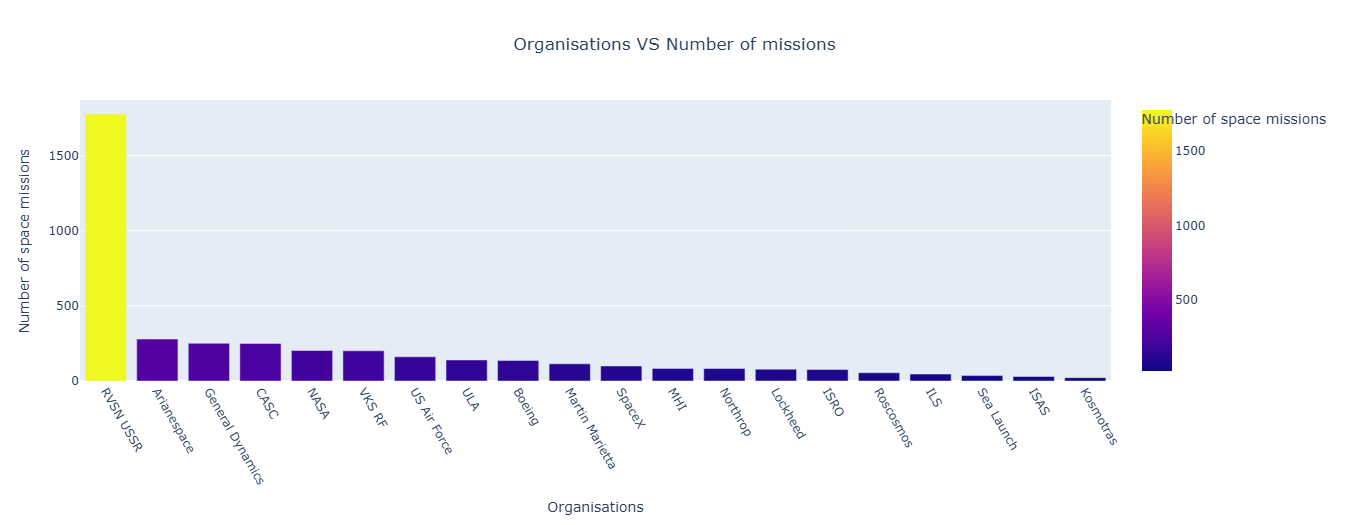

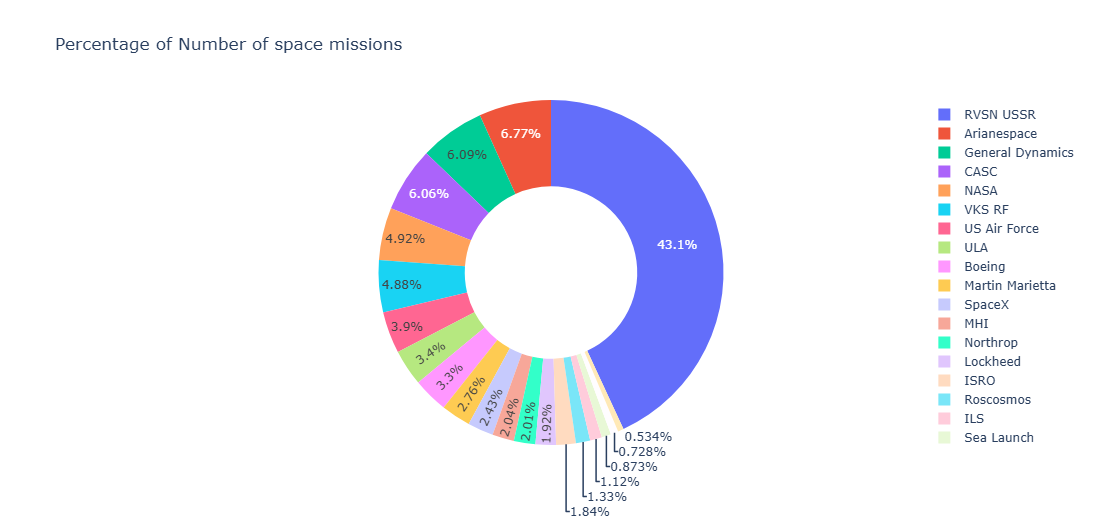

# Number of Active versus Retired Rockets

How many rockets are active compared to those that are decomissioned?

In [ ]:
df_by_activity = clean_df_data['Rocket_Status'].value_counts()
df_by_activity

,count
Rocket_Status,
StatusRetired,3534
StatusActive,789


In [ ]:
fig_pie = px.pie(
    df_by_activity,
    names = df_by_activity.index,
    values = df_by_activity.values,

    title='Rocket status',
    width=500,
    height=500,
    hole = 0.5
)

fig_pie.show()

<!doctype html>

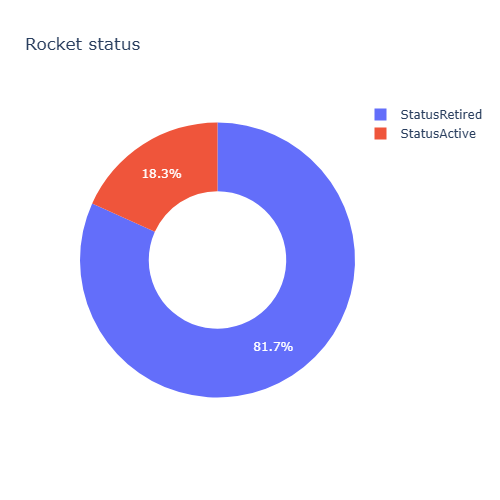

# Distribution of Mission Status

How many missions were successful?
How many missions failed?

In [ ]:
df_by_success = clean_df_data['Mission_Status'].value_counts()
df_by_success

,count
Mission_Status,
Success,3878
Failure,339
Partial Failure,102
Prelaunch Failure,4


In [ ]:
fig_success_bar = px.bar(
    data_frame=df_by_success,
    x = df_by_success.index,
    y = df_by_success.values,
    color = df_by_success.values,
    title = 'Number of space missions'
  )

fig_success_bar.update_layout(title_x=0.5)

# fig_success_bar.update_xaxes(tickangle = 60)
fig_success_bar.show()


<!doctype html>

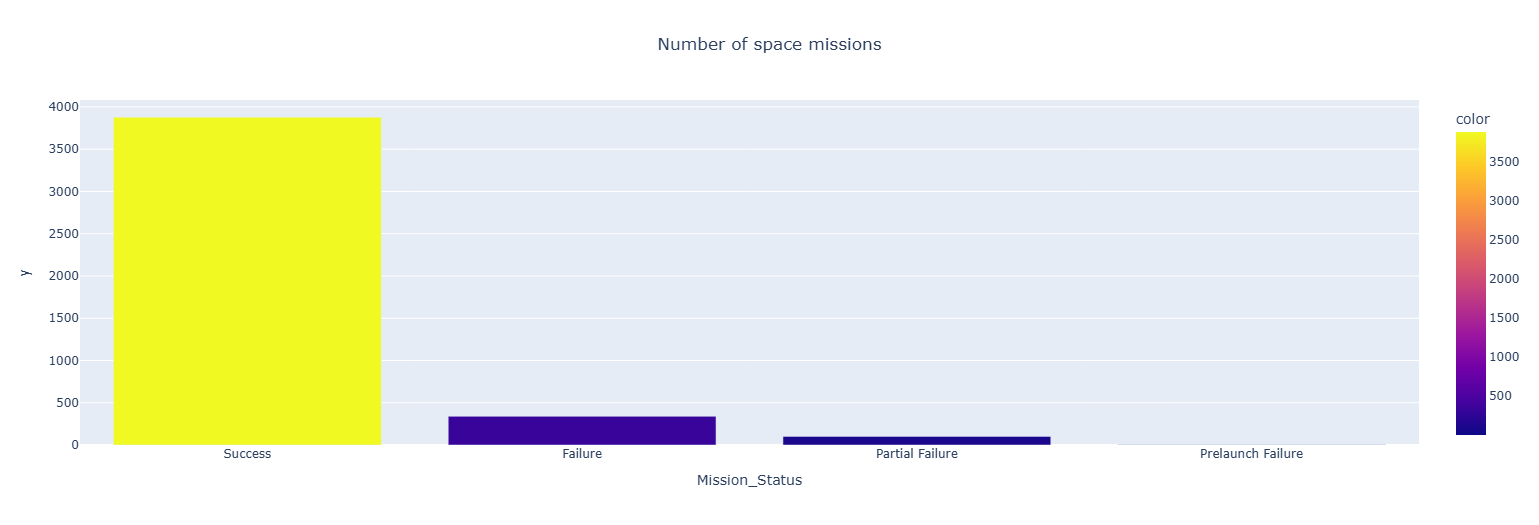

In [ ]:

# ------------------------------------------------------------------------
fig_success_pie = px.pie(
    df_by_success,
    names = df_by_success.index,
    values = df_by_success.values,
    title='Number of space missions',
    hole = 0.5
)

fig_success_pie.show()

<!doctype html>

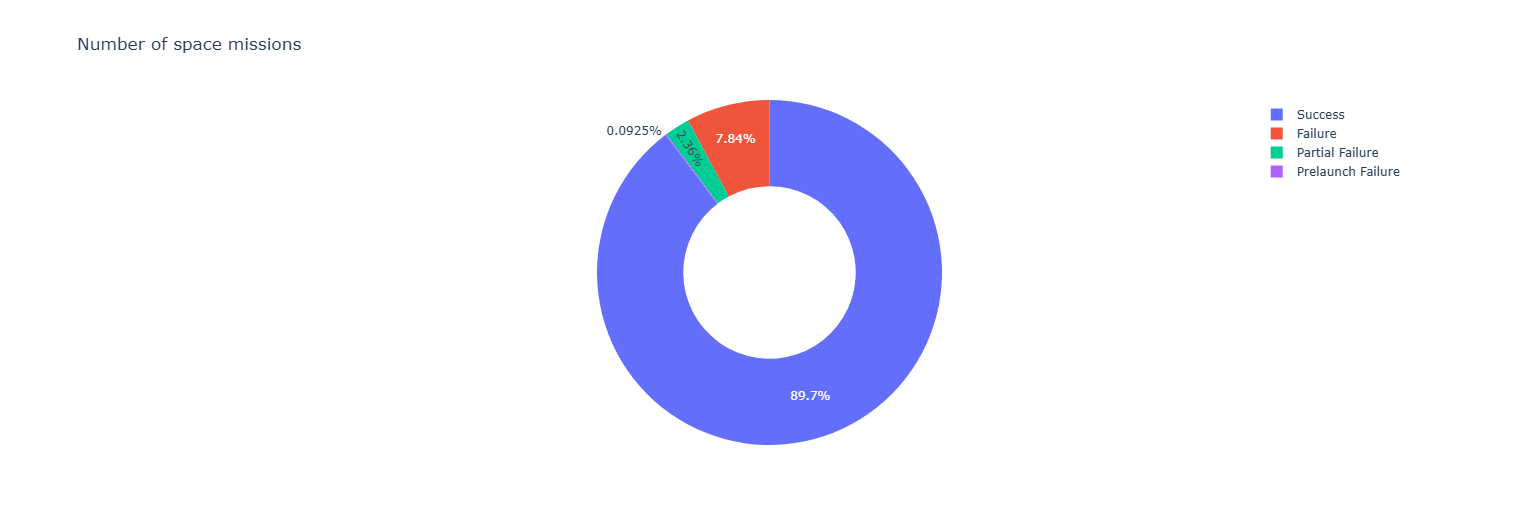

# How Expensive are the Launches?

Create a histogram and visualise the distribution. The price column is given in USD millions (careful of missing values).

In [ ]:
clean_df_data.Price = pd.to_numeric(df_data.Price.fillna(value=0).astype(str).str.replace(',', ""))
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [ ]:
df_price_data = clean_df_data[['Organisation', 'Price']]
df_price_data_sum = df_price_data.groupby('Organisation')['Price'].agg(['sum']).sort_values(by = 'sum', ascending=False)[:10]
df_price_data_sum


,sum
Organisation,
NASA,"76,280.00"
Arianespace,"16,345.00"
ULA,"14,798.00"
RVSN USSR,"10,000.00"
CASC,"6,310.51"
SpaceX,"5,444.00"
Northrop,"3,930.00"
MHI,"3,532.50"
ISRO,"2,177.00"


In [ ]:
fig_price = px.bar(
    data_frame = df_price_data_sum,
    x = df_price_data_sum.index,
    y = 'sum'
)

fig_price.update_xaxes(tickangle = 60)

fig_price.show()


fig_price = px.pie(
    df_price_data_sum,
    names = df_price_data_sum.index,
    values = 'sum',
    hole = 0.5
)

fig_price.show()

<!doctype html>

<!doctype html>

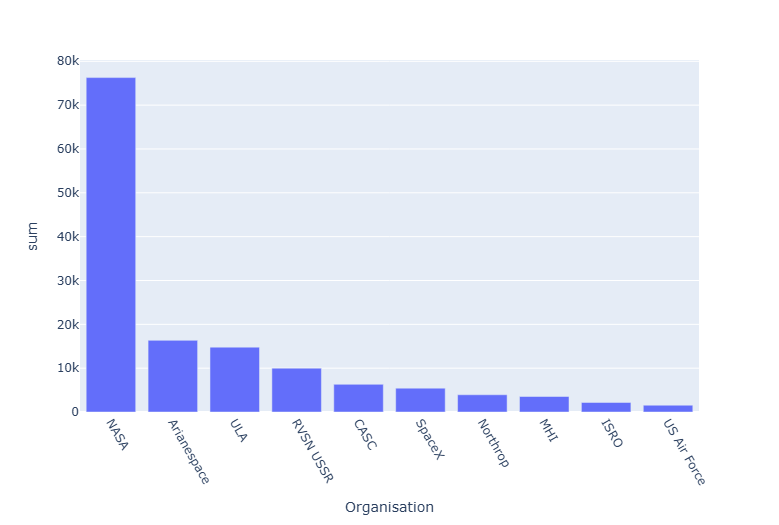

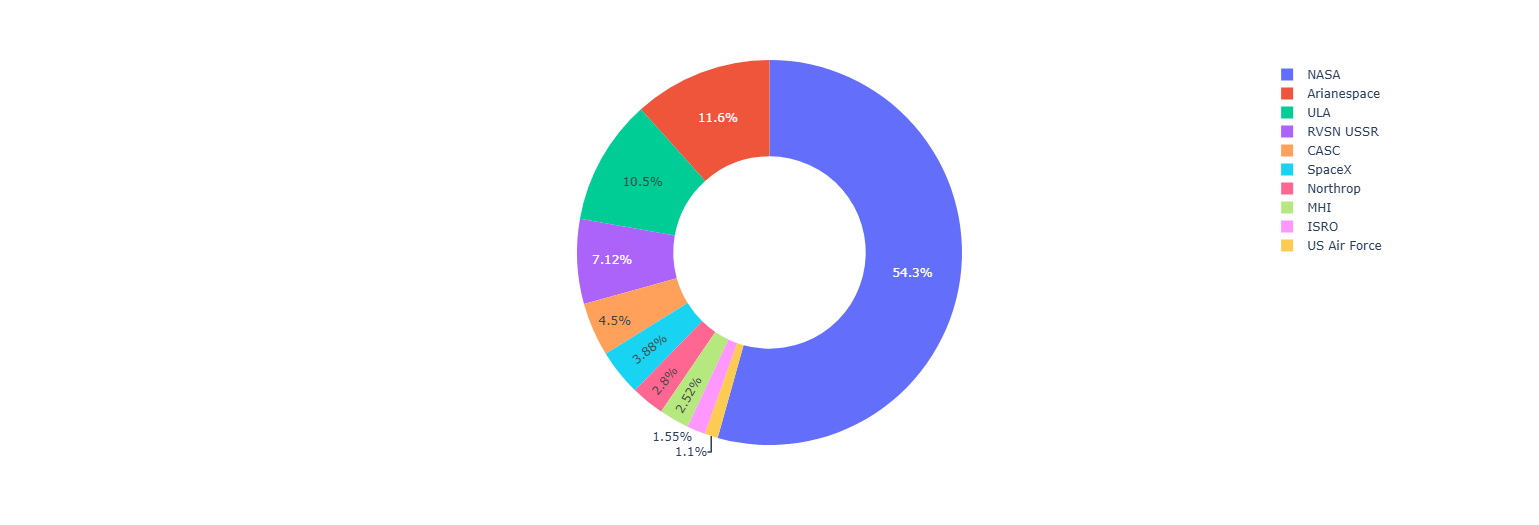

In [ ]:
clean_df_data['country'] = clean_df_data['Location'].str.rsplit(',', n=1).str[-1].str.strip()


In [ ]:
clean_df_data.sample(n= 5)

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,country
2104,NASA,"LC-39A, Kennedy Space Center, Florida, USA","Thu Oct 03, 1985 15:15 UTC",Space Shuttle Atlantis | STS-51-J,StatusRetired,450.00,Success,USA
3829,Martin Marietta,"SLC-40, Cape Canaveral AFS, Florida, USA","Thu Nov 03, 1966 13:50 UTC","Titan IIIC | Gemini B, OV4-3, & OV4-1R/T",StatusRetired,0.00,Success,USA
736,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Feb 11, 2010 15:23 UTC",Atlas V 401 | SDO,StatusActive,109.00,Success,USA
3956,RVSN USSR,"Site 31/6, Baikonur Cosmodrome, Kazakhstan","Tue Jul 13, 1965 11:00 UTC",Vostok-2 | Zenit-2 n†­28,StatusRetired,0.00,Failure,Kazakhstan
1382,NASA,"LC-39A, Kennedy Space Center, Florida, USA","Tue Jul 01, 1997 18:02 UTC",Space Shuttle Columbia | STS-94,StatusRetired,450.00,Success,USA


# Use a Choropleth Map to Show the Number of Launches by Country

* Create a choropleth map using [the plotly documentation](https://plotly.com/python/choropleth-maps/)
* Experiment with [plotly's available colours](https://plotly.com/python/builtin-colorscales/). I quite like the sequential colour `matter` on this map.
* You'll need to extract a `country` feature as well as change the country names that no longer exist.

Wrangle the Country Names

You'll need to use a 3 letter country code for each country. You might have to change some country names.

* Russia is the Russian Federation
* New Mexico should be USA
* Yellow Sea refers to China
* Shahrud Missile Test Site should be Iran
* Pacific Missile Range Facility should be USA
* Barents Sea should be Russian Federation
* Gran Canaria should be USA


You can use the iso3166 package to convert the country names to Alpha3 format.

In [ ]:
to_be_changed = {
    'Russia' : 'Russian Fedaration',
    'New Mexico' : "USA",
    'Yellow Sea' : "China",
    'Shahrud Missile Test Site' : "Iran",
    "Pacific Missile Range Facility" : "USA",
    'Barents Sea' : "Russian Fedaration",
    "Gran Canaria" : "USA"
  }

In [ ]:
clean_df_data['country'] = clean_df_data['country'].replace(to_be_changed)

In [ ]:
clean_df_data['country'].unique()

array(['USA', 'China', 'Kazakhstan', 'Japan', 'Israel', 'New Zealand',
       'Russian Fedaration', 'Iran', 'France', 'India', 'North Korea',
       'Pacific Ocean', 'South Korea', 'Brazil', 'Kenya', 'Australia'],
      dtype=object)

In [ ]:
# countries.get('Russian Fedaration')

In [ ]:
countries.get("China").alpha3

'CHN'

In [ ]:
clean_df_data["alpha3"] = coco.convert(names=clean_df_data["country"], to="ISO3")

In [ ]:
clean_df_data['alpha3'] = clean_df_data['alpha3'].replace('not found', np.nan)

In [ ]:
clean_df_data[clean_df_data.country == 'Pacific Ocean']

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,country,alpha3
556,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Sat May 24, 2014 21:09 UTC",Zenit-3 SL | Eutelsat-3B,StatusActive,0.00,Success,Pacific Ocean,NaN
617,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Fri Feb 01, 2013 06:55 UTC",Zenit-3 SL | Intelsat-27,StatusActive,0.00,Failure,Pacific Ocean,NaN
625,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Mon Dec 03, 2012 20:43 UTC",Zenit-3 SL | Eutelsat-70B,StatusActive,0.00,Success,Pacific Ocean,NaN
636,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Sun Aug 19, 2012 06:54 UTC",Zenit-3 SL | Intelsat-21,StatusActive,0.00,Success,Pacific Ocean,NaN
645,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Fri Jun 01, 2012 05:22 UTC",Zenit-3 SL | Intelsat-19,StatusActive,0.00,Success,Pacific Ocean,NaN
671,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Sat Sep 24, 2011 20:17 UTC",Zenit-3 SL | Atlantic Bird 7,StatusActive,0.00,Success,Pacific Ocean,NaN
773,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Mon Apr 20, 2009 08:15 UTC",Zenit-3 SL | Sicral-1B,StatusActive,0.00,Success,Pacific Ocean,NaN
802,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Wed Sep 24, 2008 09:27 UTC",Zenit-3 SL | Galaxy 19,StatusActive,0.00,Success,Pacific Ocean,NaN
810,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Wed Jul 16, 2008 05:20 UTC",Zenit-3 SL | EchoStar XI,StatusActive,0.00,Success,Pacific Ocean,NaN
820,Sea Launch,"LP Odyssey, Kiritimati Launch Area, Pacific Ocean","Wed May 21, 2008 09:42 UTC",Zenit-3 SL | Galaxy 18,StatusActive,0.00,Success,Pacific Ocean,NaN


In [ ]:
cholopleth_data = clean_df_data[['alpha3', 'country']].value_counts().reset_index(name="count")
cholopleth_data

,alpha3,country,count
0,RUS,Russian Fedaration,1398
1,USA,USA,1351
2,KAZ,Kazakhstan,701
3,FRA,France,303
4,CHN,China,268
5,JPN,Japan,126
6,IND,India,76
7,IRN,Iran,14
8,NZL,New Zealand,13
9,ISR,Israel,11


In [ ]:
fig_choropleth = px.choropleth(
    cholopleth_data,
    locations="alpha3",  # ISO-3 codes for positioning
    color="count",  # Value determining color intensity
    hover_name="country",  # Tooltip title
    color_continuous_scale=px.colors.sequential.Plasma,

)

In [ ]:
fig_choropleth.show()

<!doctype html>

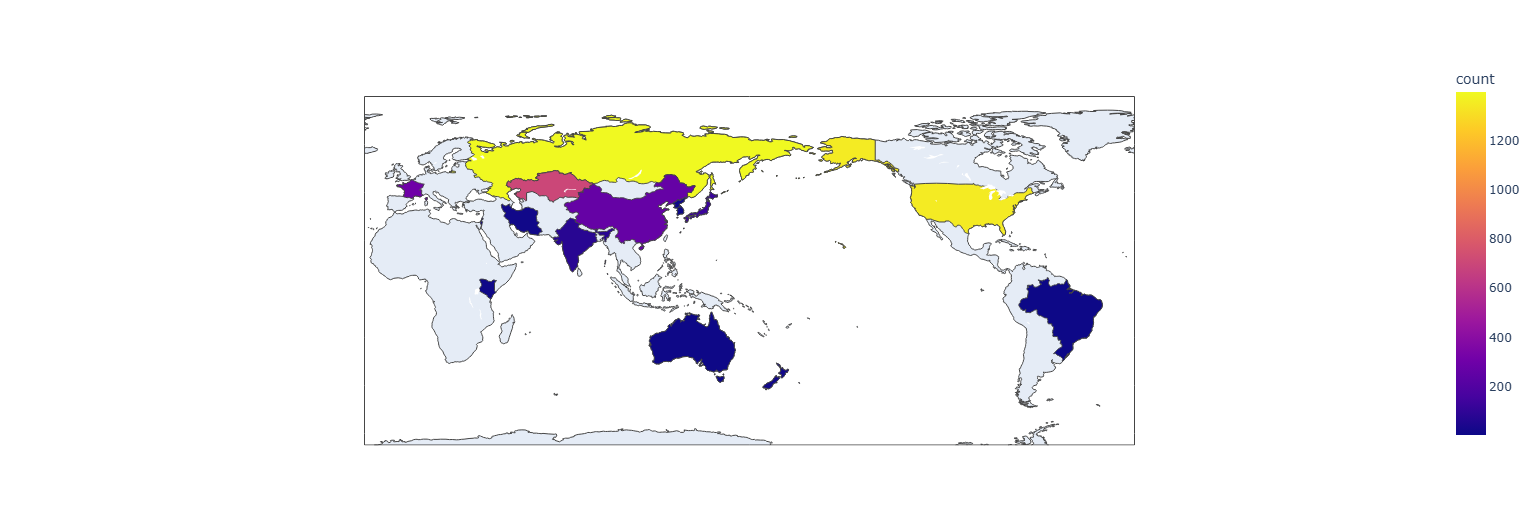

# Use a Choropleth Map to Show the Number of Failures by Country


In [ ]:
failure_choropleth = clean_df_data[clean_df_data.Mission_Status=='Failure'][['country', 'alpha3']].value_counts().reset_index(name = 'count')
failure_choropleth

,country,alpha3,count
0,USA,USA,129
1,Kazakhstan,KAZ,72
2,Russian Fedaration,RUS,63
3,China,CHN,19
4,France,FRA,13
5,Japan,JPN,10
6,Iran,IRN,8
7,India,IND,8
8,North Korea,PRK,3
9,Australia,AUS,3


In [ ]:
failure_choropleth_plot = px.choropleth(
    failure_choropleth,
    locations='alpha3',
    color= 'count',
    hover_name = 'country',
    color_continuous_scale=px.colors.sequential.Plasma,

)

In [ ]:
failure_choropleth_plot.show()

<!doctype html>

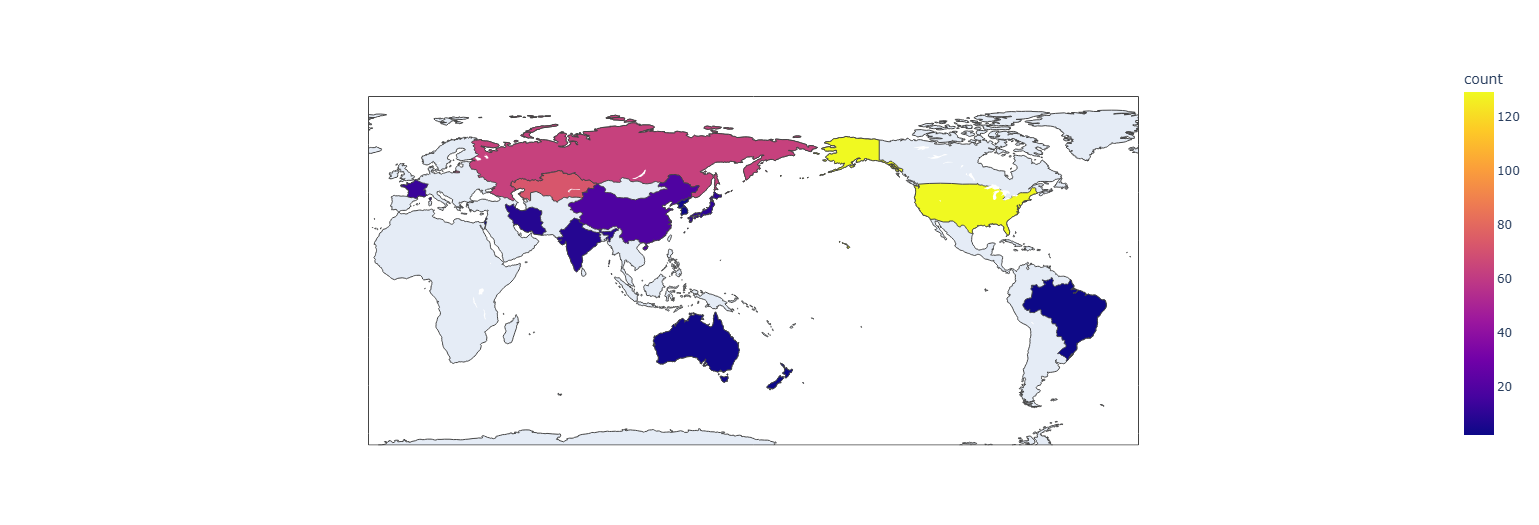

# Create a Plotly Sunburst Chart of the countries, organisations, and mission status.

In [ ]:
sunburst_plot = px.sunburst(
    clean_df_data,
    path= ['country', 'Organisation', 'Mission_Status'],
    color_continuous_scale='RdBu'
)

In [ ]:
sunburst_plot.show()

<!doctype html>

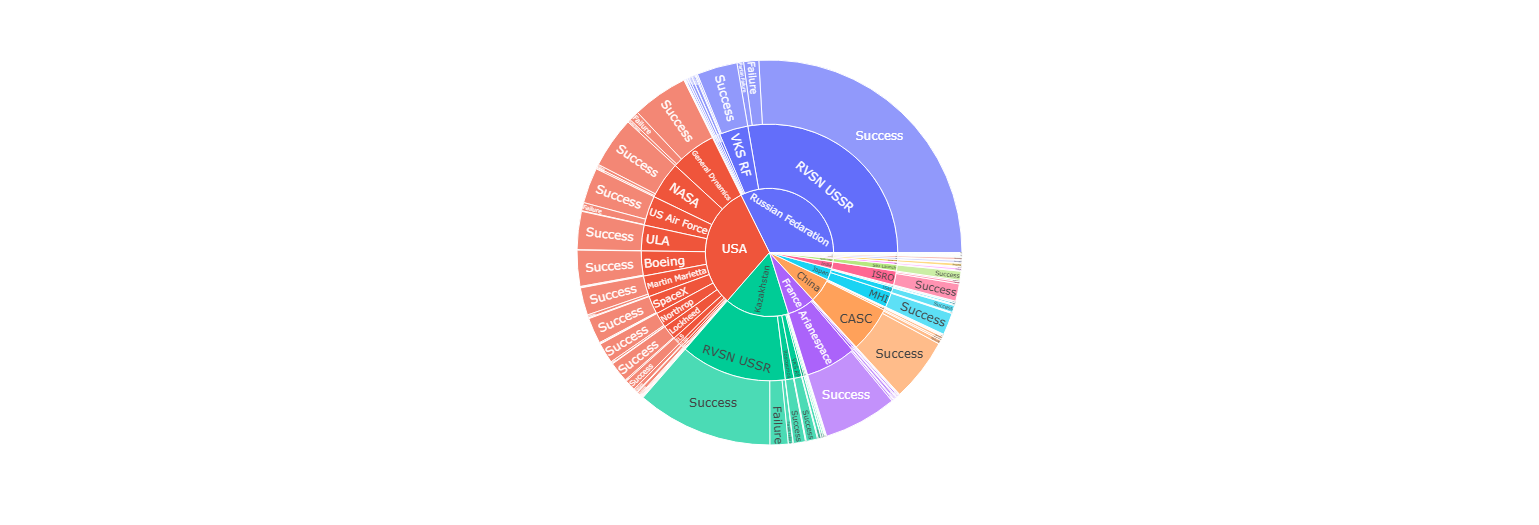

# Analyse the Total Amount of Money Spent by Organisation on Space Missions

In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4324 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0.1    4324 non-null   int64 
 1   Unnamed: 0      4324 non-null   int64 
 2   Organisation    4324 non-null   object
 3   Location        4324 non-null   object
 4   Date            4324 non-null   object
 5   Detail          4324 non-null   object
 6   Rocket_Status   4324 non-null   object
 7   Price           964 non-null    object
 8   Mission_Status  4324 non-null   object
dtypes: int64(2), object(7)
memory usage: 304.2+ KB


In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Organisation    4323 non-null   object 
 1   Location        4323 non-null   object 
 2   Date            4323 non-null   object 
 3   Detail          4323 non-null   object 
 4   Rocket_Status   4323 non-null   object 
 5   Price           4323 non-null   float64
 6   Mission_Status  4323 non-null   object 
 7   country         4323 non-null   object 
 8   alpha3          4287 non-null   object 
dtypes: float64(1), object(8)
memory usage: 337.7+ KB


In [ ]:
reqd_data = clean_df_data.groupby('country')['Price'].sum().sort_values(ascending=False)
reqd_data = reqd_data[reqd_data.values != 0]
reqd_data

,Price
country,
USA,"105,287.32"
France,"16,285.00"
Kazakhstan,"12,150.50"
China,"6,338.81"
Japan,"3,700.50"
Russian Fedaration,"2,189.30"
India,"2,177.00"
New Zealand,97.50


In [ ]:
fig_total_amt_pie = px.pie(
    reqd_data,
    names = reqd_data.index,
    values= reqd_data.values,
    title= 'Pie Chart of spendings in Space Exploration',


)


fig_total_amt_pie.show()



fig_total_amt_bar_h = px.bar(
    reqd_data,
    y = reqd_data.index,
    x = reqd_data.values/ 10000,
    color = reqd_data.index,
    title= 'Horizontal bar plot of spendings in Space Exploration',

)

fig_total_amt_bar_h.update_traces(
    textfont_size=12,
    textangle=0,
    textposition="outside",
    cliponaxis=False
)

fig_total_amt_bar_h.update_xaxes(
    title_text="Expanses in 10 MILLIONS"
)

fig_total_amt_bar_h.show()

<!doctype html>

<!doctype html>

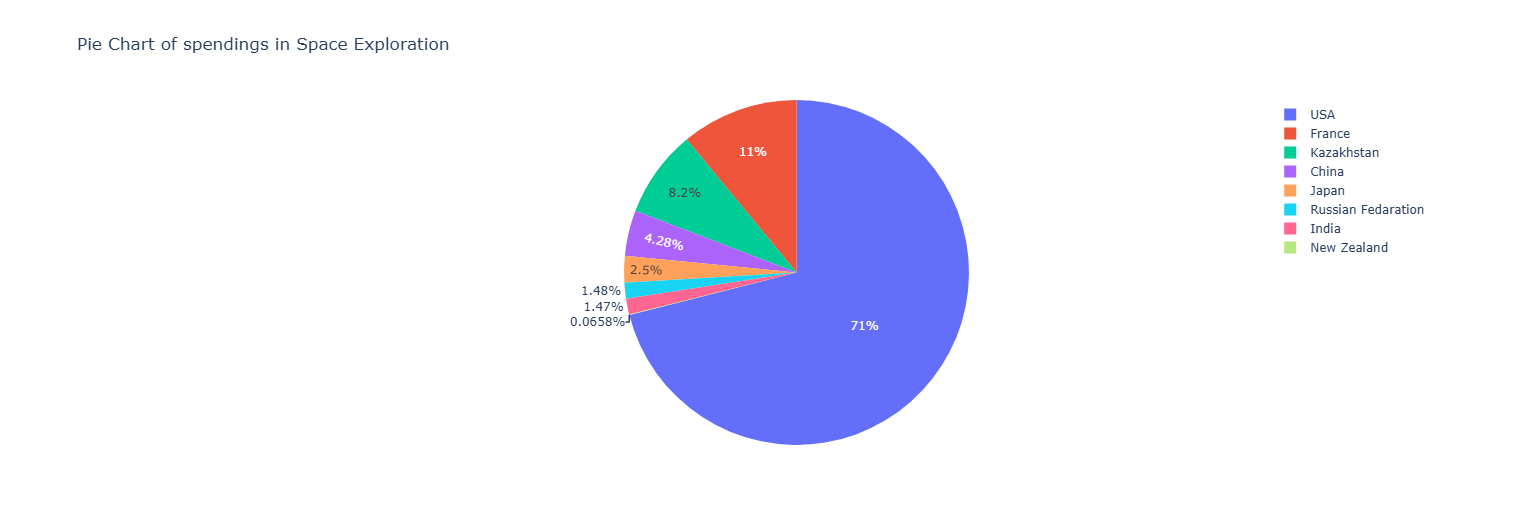

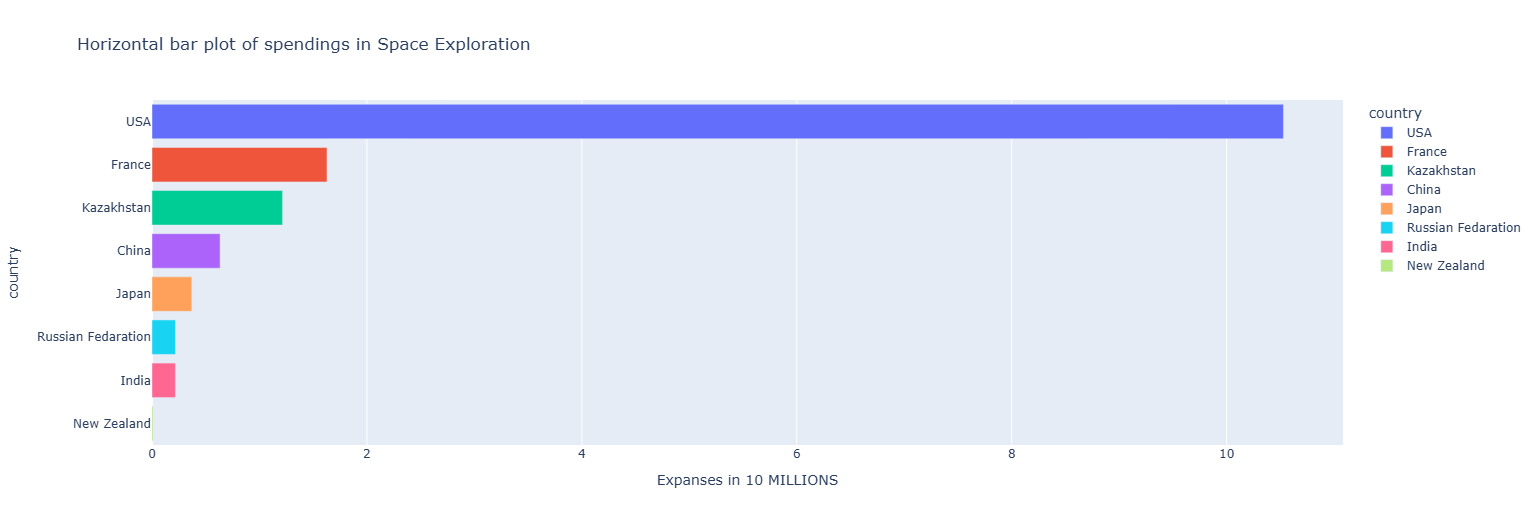

# Analyse the Amount of Money Spent by Organisation per Launch

In [ ]:
reqd_data_by_org = clean_df_data.groupby('Organisation')['Price'].sum().sort_values(ascending= False)
reqd_data_by_org = reqd_data_by_org[reqd_data_by_org.values != 0 ][:10]
reqd_data_by_org

,Price
Organisation,
NASA,"76,280.00"
Arianespace,"16,345.00"
ULA,"14,798.00"
RVSN USSR,"10,000.00"
CASC,"6,310.51"
SpaceX,"5,444.00"
Northrop,"3,930.00"
MHI,"3,532.50"
ISRO,"2,177.00"


In [ ]:
amt_by_org_pie =  px.pie(
    reqd_data_by_org,
    names = reqd_data_by_org.index,
    values= reqd_data_by_org.values,
    title= 'Pie Chart of spendings in Space Exploration by Organization',

)

amt_by_org_pie.show()



fig_total_amt_bar_h = px.bar(
    reqd_data_by_org,
    y = reqd_data_by_org.index,
    x = reqd_data_by_org.values/ 10000,
    color = reqd_data_by_org.index,
    title= 'Horizontal bar plot of spendings in Space Exploration by Organization',

)

fig_total_amt_bar_h.update_traces(
    textfont_size=12,
    textangle=0,
    textposition="outside",
    cliponaxis=False
)

fig_total_amt_bar_h.update_xaxes(
    title_text="Expanses in 10 MILLIONS"
)

fig_total_amt_bar_h.show()

<!doctype html>

<!doctype html>

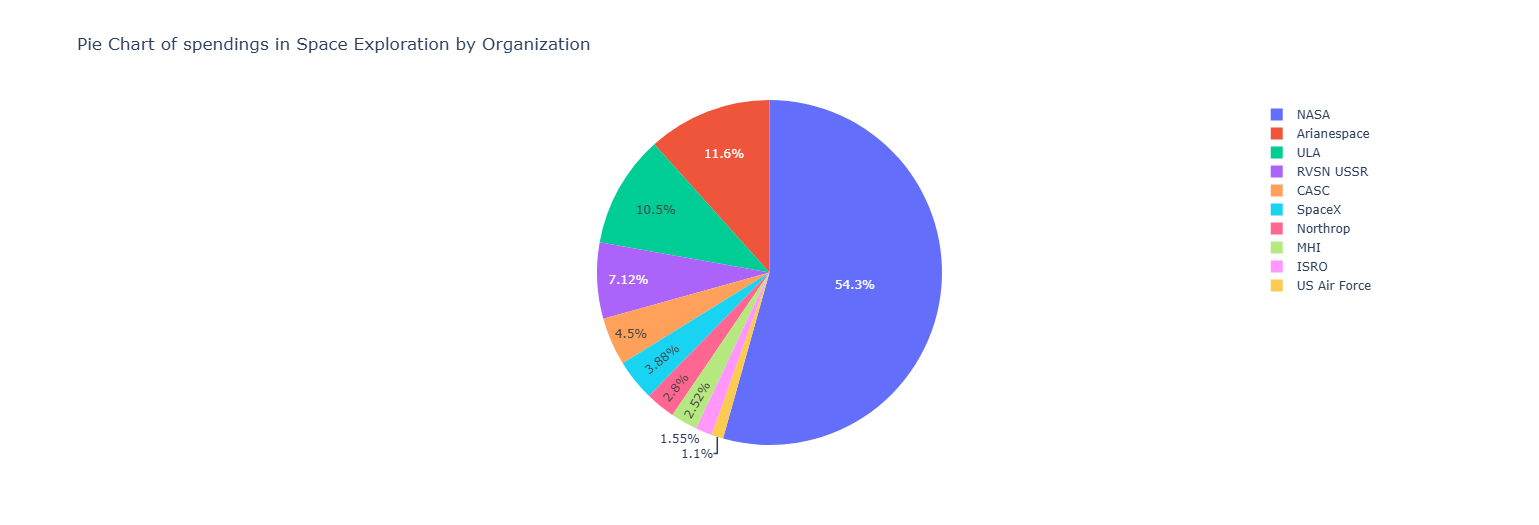

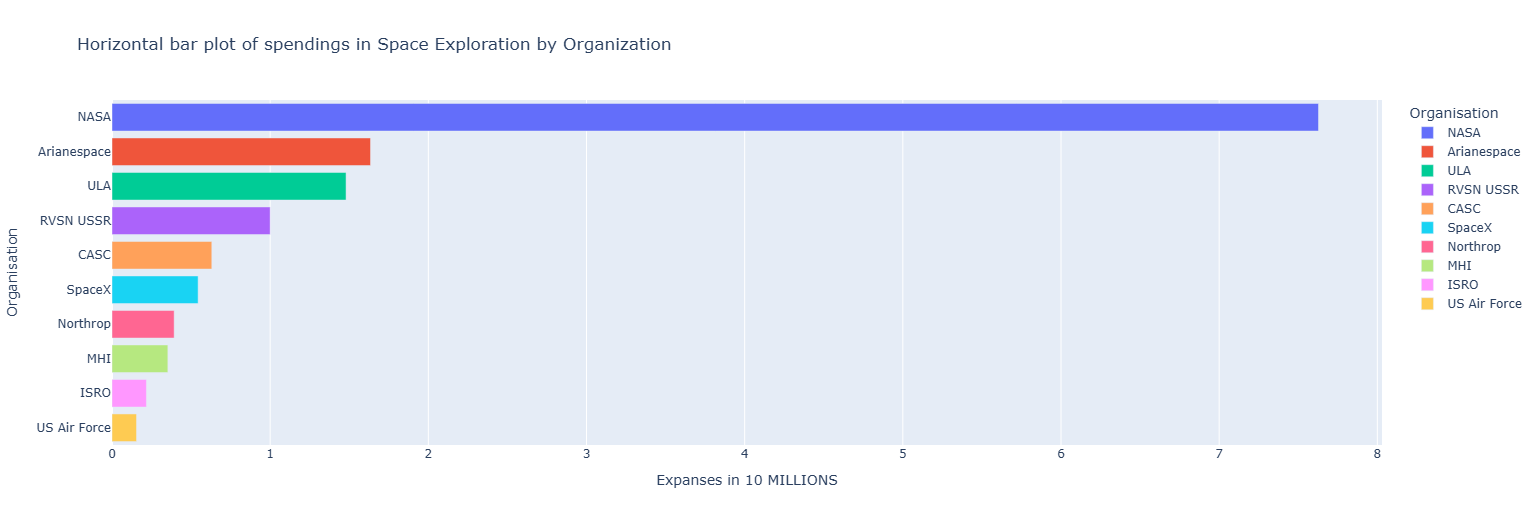

# Chart the Number of Launches per Year

In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Organisation    4323 non-null   object 
 1   Location        4323 non-null   object 
 2   Date            4323 non-null   object 
 3   Detail          4323 non-null   object 
 4   Rocket_Status   4323 non-null   object 
 5   Price           4323 non-null   float64
 6   Mission_Status  4323 non-null   object 
 7   country         4323 non-null   object 
 8   alpha3          4287 non-null   object 
dtypes: float64(1), object(8)
memory usage: 337.7+ KB


In [ ]:
clean_df_data['Date']

,Date
0,"Fri Aug 07, 2020 05:12 UTC"
1,"Thu Aug 06, 2020 04:01 UTC"
2,"Tue Aug 04, 2020 23:57 UTC"
3,"Thu Jul 30, 2020 21:25 UTC"
4,"Thu Jul 30, 2020 11:50 UTC"
...,...
4319,"Wed Feb 05, 1958 07:33 UTC"
4320,"Sat Feb 01, 1958 03:48 UTC"
4321,"Fri Dec 06, 1957 16:44 UTC"
4322,"Sun Nov 03, 1957 02:30 UTC"


In [ ]:
clean_df_data['Date'] = pd.to_datetime(
    clean_df_data['Date'],
    format='mixed',
    utc=True
)

In [ ]:
clean_df_data['Year'] = clean_df_data['Date'].dt.year
clean_df_data['Year'].info()

<class 'pandas.core.series.Series'>
Index: 4323 entries, 0 to 4323
Series name: Year
Non-Null Count  Dtype
--------------  -----
4323 non-null   int32
dtypes: int32(1)
memory usage: 50.7 KB


In [ ]:
launch_by_year_df = clean_df_data.groupby('Year').size().reset_index(name = 'No_of_launches')
launch_by_year_df

,Year,No_of_launches
0,1957,3
1,1958,28
2,1959,20
3,1960,39
4,1961,52
...,...,...
59,2016,90
60,2017,92
61,2018,117
62,2019,109


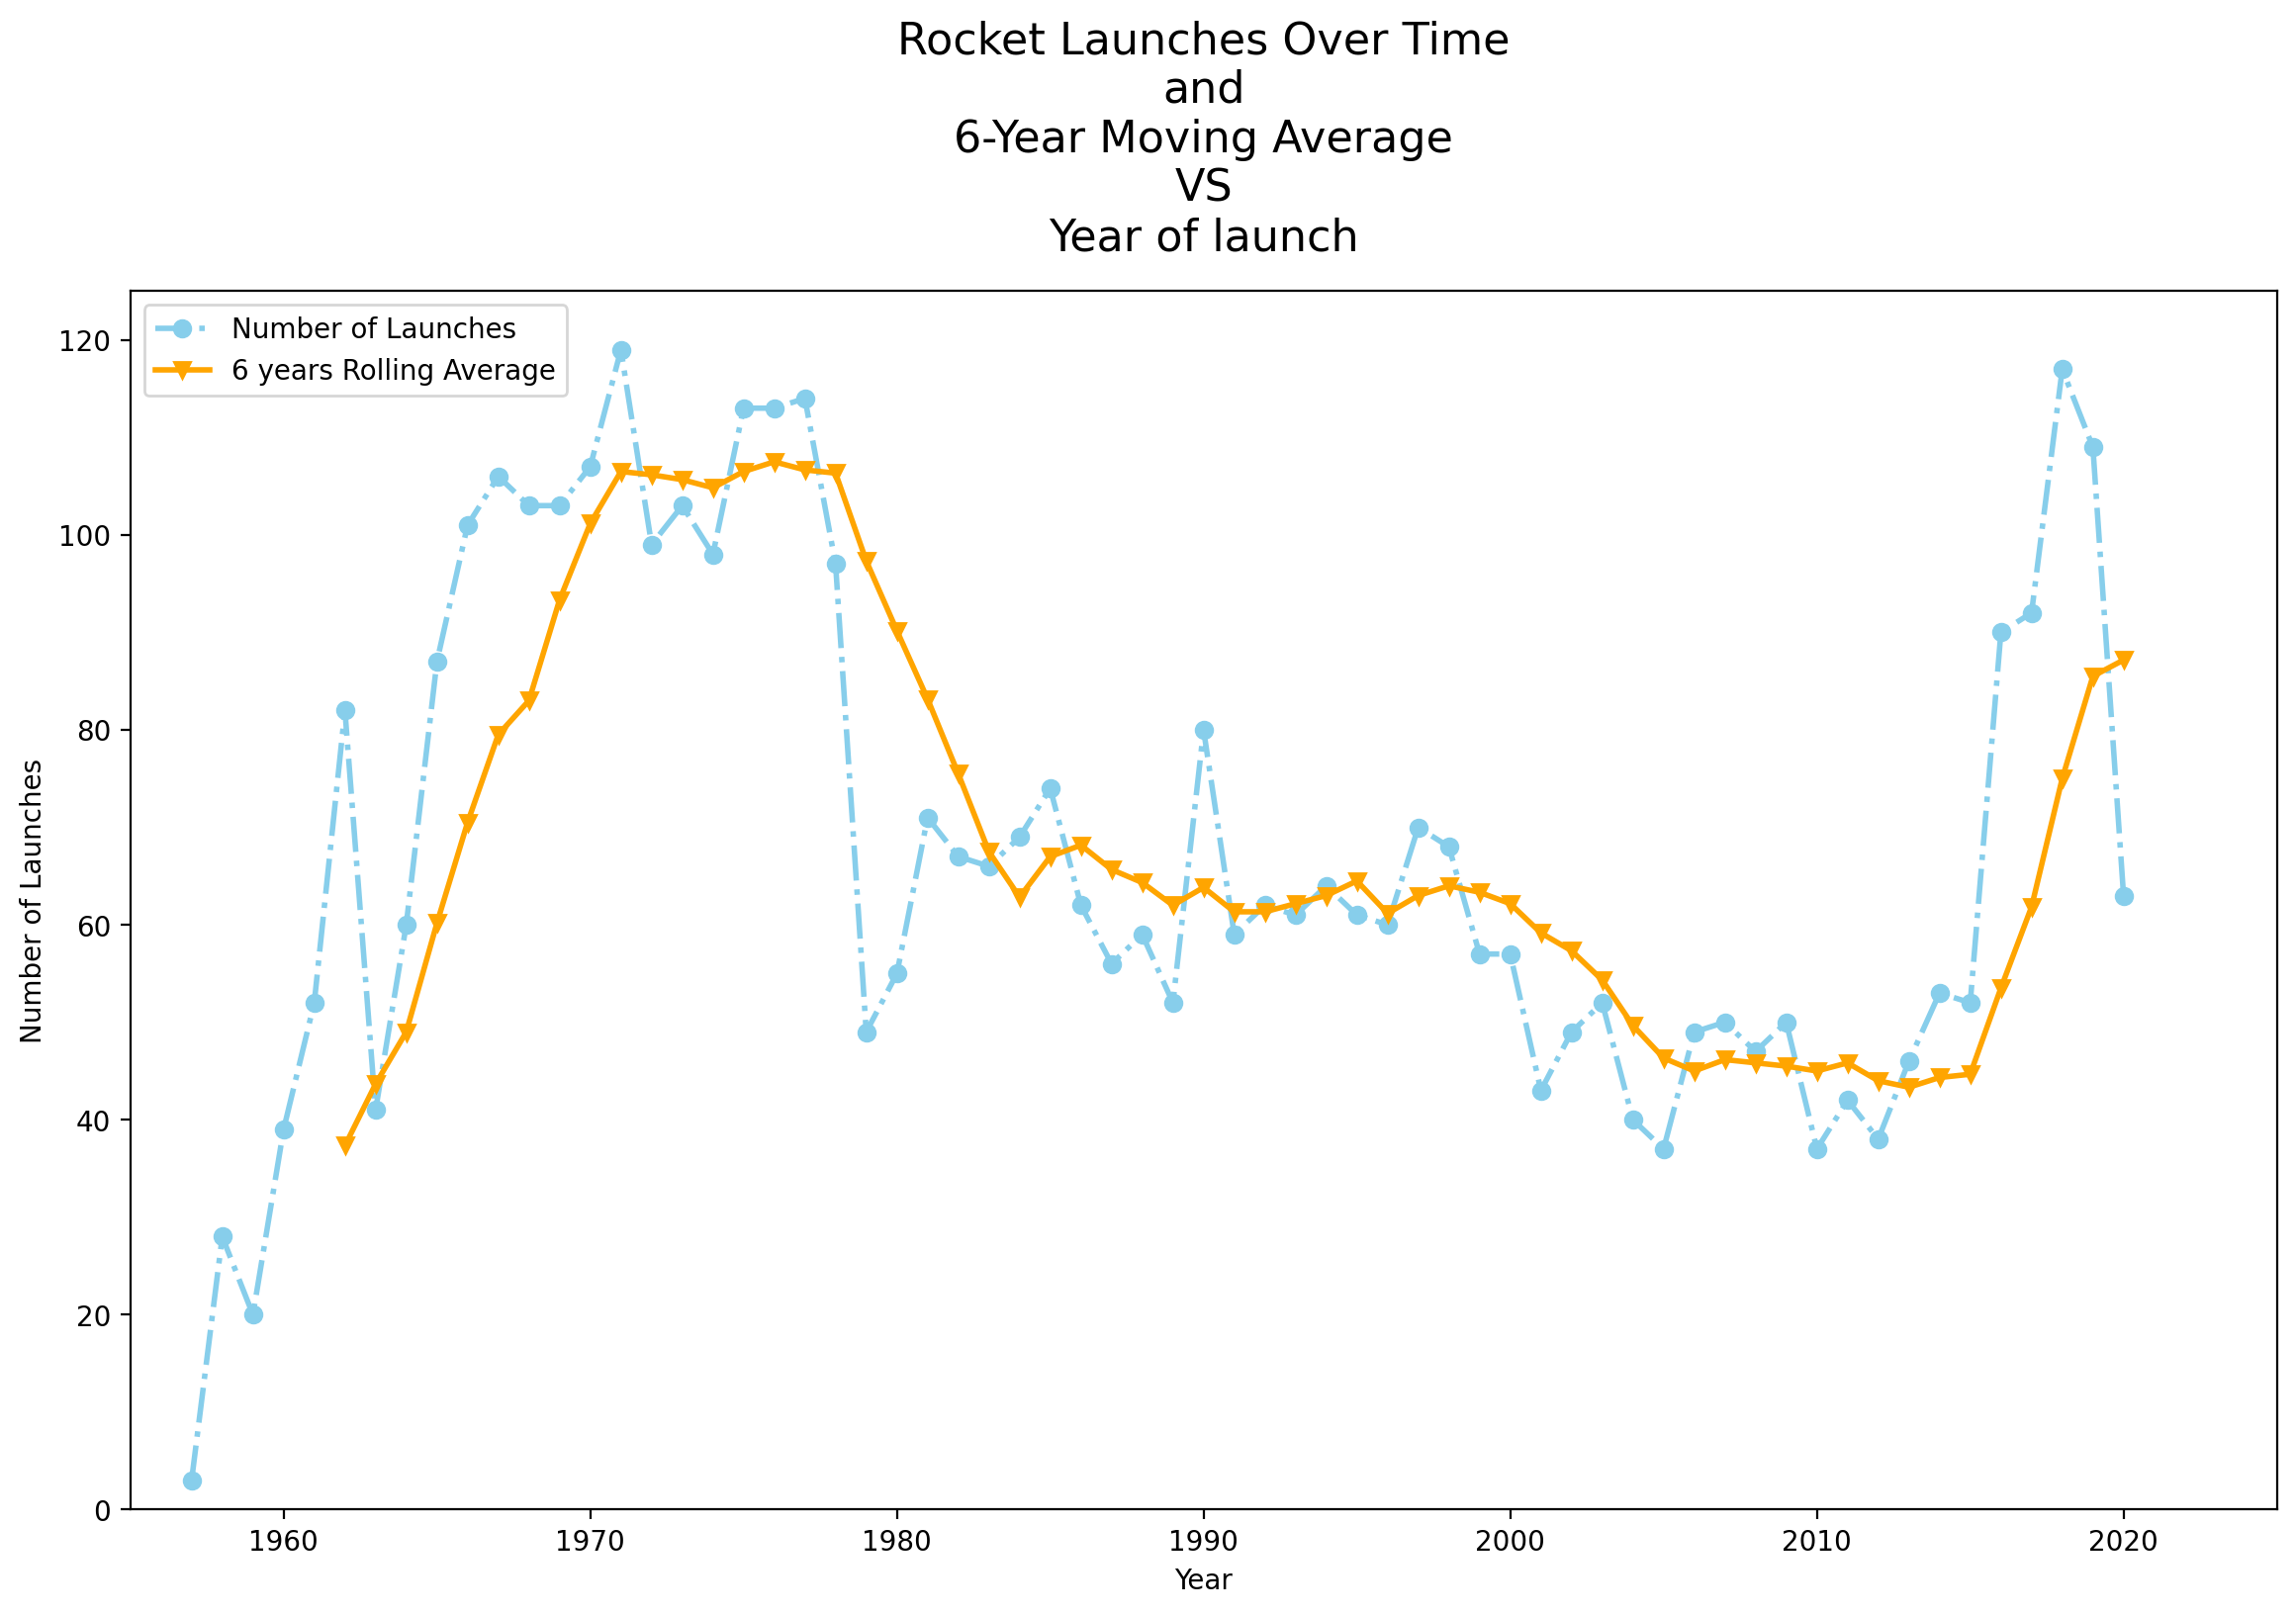

In [ ]:
plt.figure(figsize=(14, 8), dpi = 200)


plt.title(
    'Rocket Launches Over Time\nand\n6-Year Moving Average\nVS\nYear of launch',
    fontsize=16,
    # fontweight='bold',
    pad=15  # Spacing between title and plot
)


plt.plot(
    launch_by_year_df.Year,
    launch_by_year_df.No_of_launches,
    marker='o',          # Adds scatter dots
    linestyle='-.',       # Connects them with a solid line
    color='skyblue',
    linewidth=2,
    markersize=6,
    label = 'Number of Launches',


)

plt.plot(
    launch_by_year_df.Year,
    launch_by_year_df.No_of_launches.rolling(window = 6).mean(),
    marker='v',          # Adds scatter dots
    linestyle='-',       # Connects them with a solid line
    color='orange',
    linewidth=2,
    markersize=6,
    label = '6 years Rolling Average',


)

plt.xlim((1955, 2025))
plt.xlabel('Year')

plt.ylim((0, 125))
plt.ylabel('Number of Launches')


plt.legend()
plt.show()

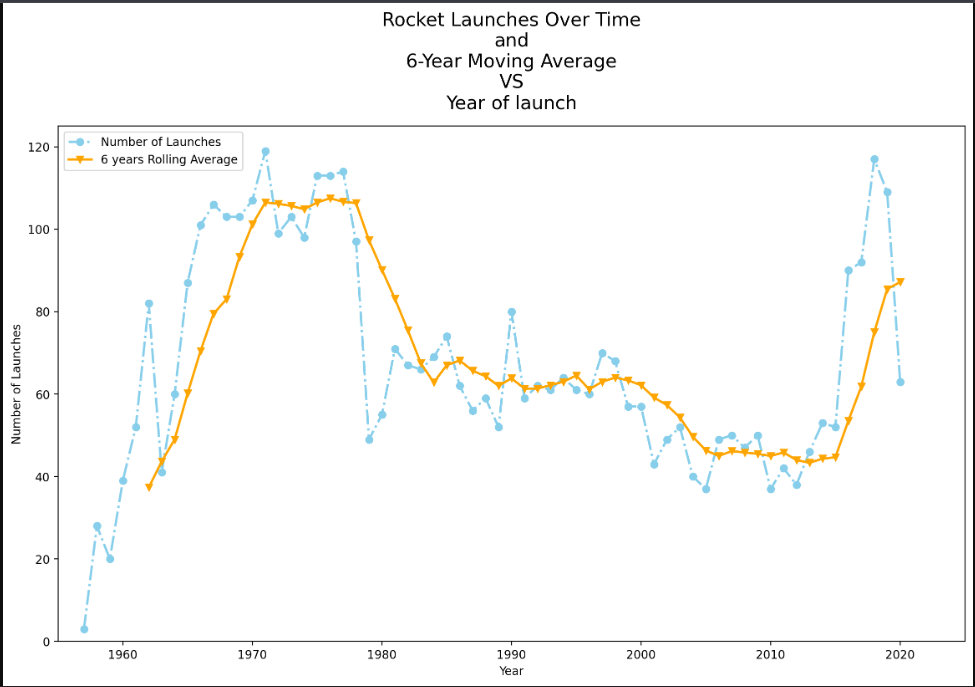

# Chart the Number of Launches Month-on-Month until the Present

Which month has seen the highest number of launches in all time? Superimpose a rolling average on the month on month time series chart.

In [ ]:
monthly_ts = clean_df_data.groupby(clean_df_data['Date'].dt.to_period('M')).size().reset_index(name='Launches')
monthly_ts['Date'] = monthly_ts['Date'].dt.to_timestamp()
monthly_ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      747 non-null    datetime64[ns]
 1   Launches  747 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 11.8 KB


/tmp/ipykernel_1166/2023781638.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_ts = clean_df_data.groupby(clean_df_data['Date'].dt.to_period('M')).size().reset_index(name='Launches')


In [ ]:
monthly_ts.describe()

,Date,Launches
count,747,747.00
mean,1989-05-06 03:45:32.530120448,5.79
min,1957-10-01 00:00:00,1.00
25%,1973-10-16 12:00:00,4.00
50%,1989-05-01 00:00:00,5.00
75%,2004-11-16 00:00:00,8.00
max,2020-08-01 00:00:00,18.00
std,NaN,3.07


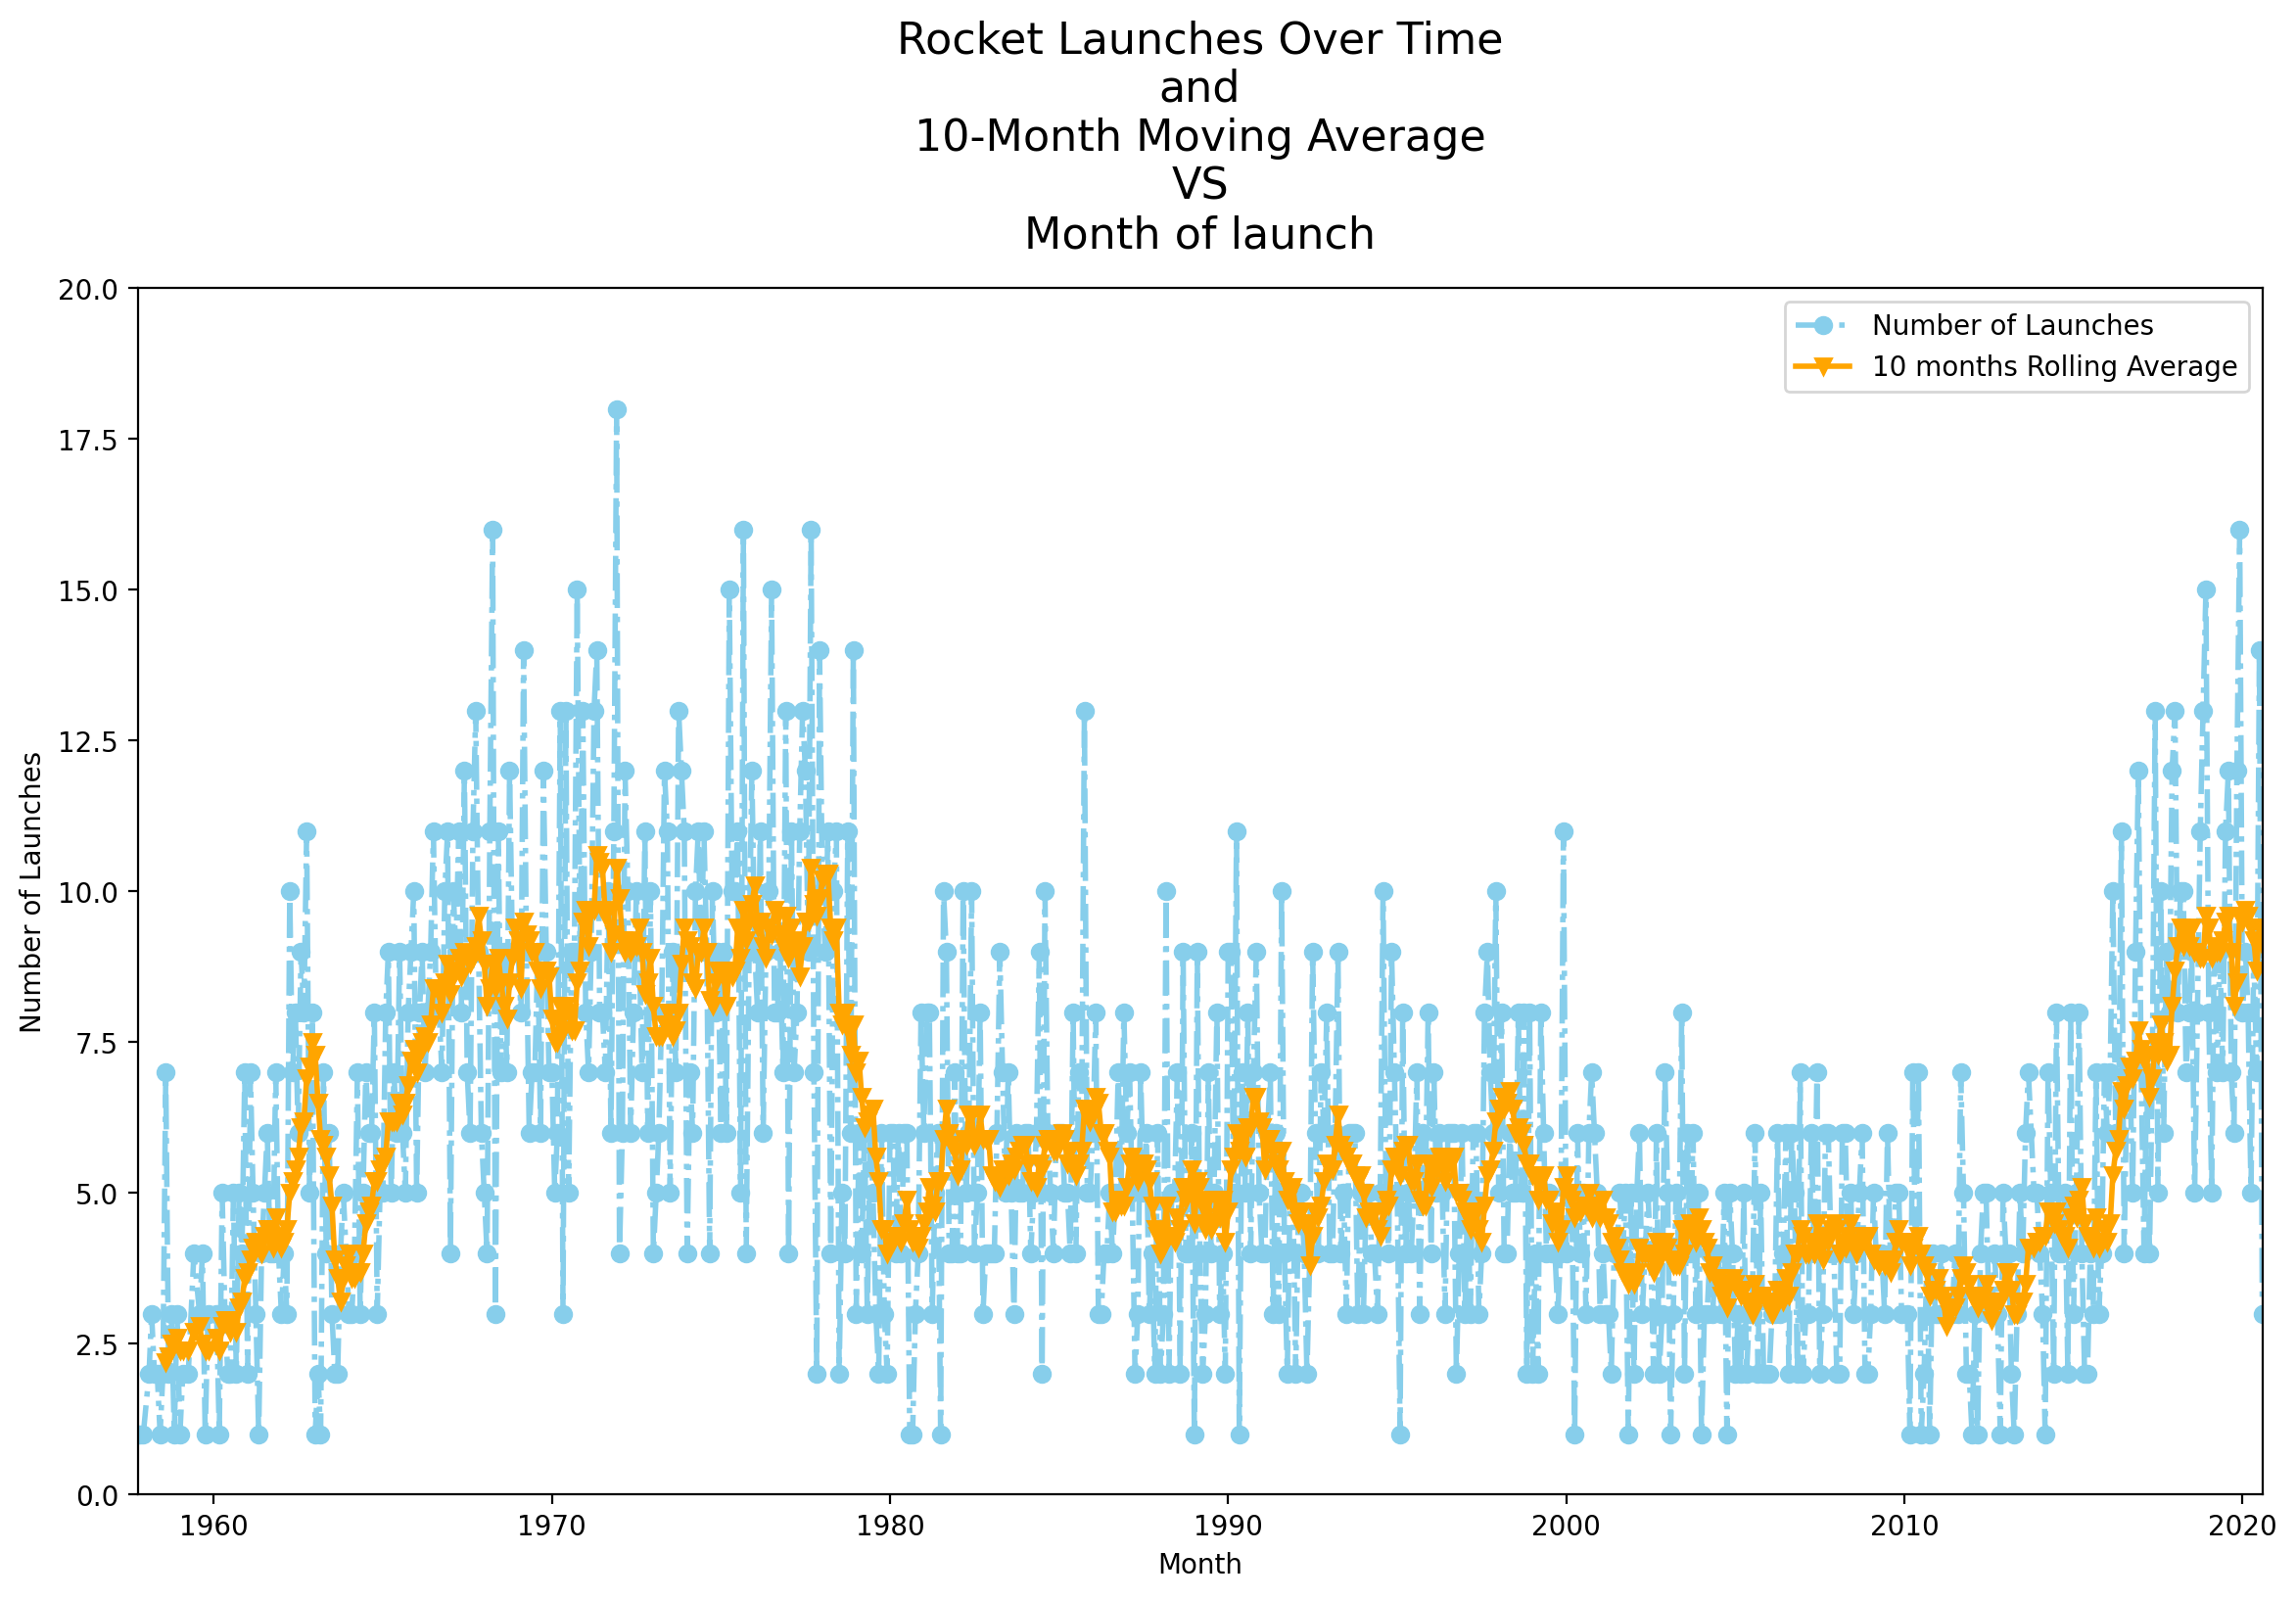

In [ ]:
plt.figure(figsize=(14, 8), dpi = 200)


plt.title(
    'Rocket Launches Over Time\nand\n10-Month Moving Average\nVS\nMonth of launch',
    fontsize=16,
    # fontweight='bold',
    pad=15  # Spacing between title and plot
)


plt.plot(
    monthly_ts.Date,
    monthly_ts.Launches,
    marker='o',          # Adds scatter dots
    linestyle='-.',       # Connects them with a solid line
    color='skyblue',
    linewidth=2,
    markersize=6,
    label = 'Number of Launches',


)

plt.plot(
    monthly_ts.Date,
    monthly_ts.Launches.rolling(window = 10).mean(),
    marker='v',          # Adds scatter dots
    linestyle='-',       # Connects them with a solid line
    color='orange',
    linewidth=2,
    markersize=6,
    label = '10 months Rolling Average',


)

plt.xlim((monthly_ts.Date.min(), monthly_ts.Date.max()))
plt.xlabel('Month')

plt.ylim((0, 20))
plt.ylabel('Number of Launches')


plt.legend()
plt.show()

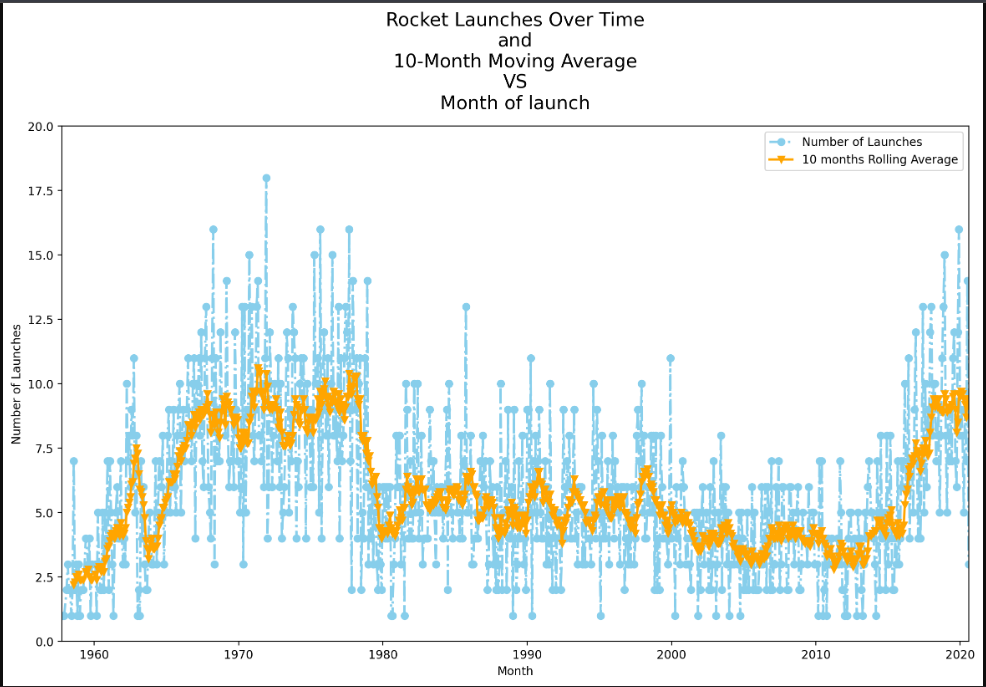

# Launches per Month: Which months are most popular and least popular for launches?

Some months have better weather than others. Which time of year seems to be best for space missions?

In [ ]:
clean_df_data['Month'] = clean_df_data.Date.dt.month
launch_by_month_df = clean_df_data.groupby('Month').size().reset_index(name = 'Launches per month')
launch_by_month_df

,Month,Launches per month
0,1,268
1,2,336
2,3,353
3,4,383
4,5,326
5,6,402
6,7,351
7,8,373
8,9,365
9,10,381


In [ ]:
print(launch_by_month_df['Launches per month'].min(), launch_by_month_df['Launches per month'].max())

268 450


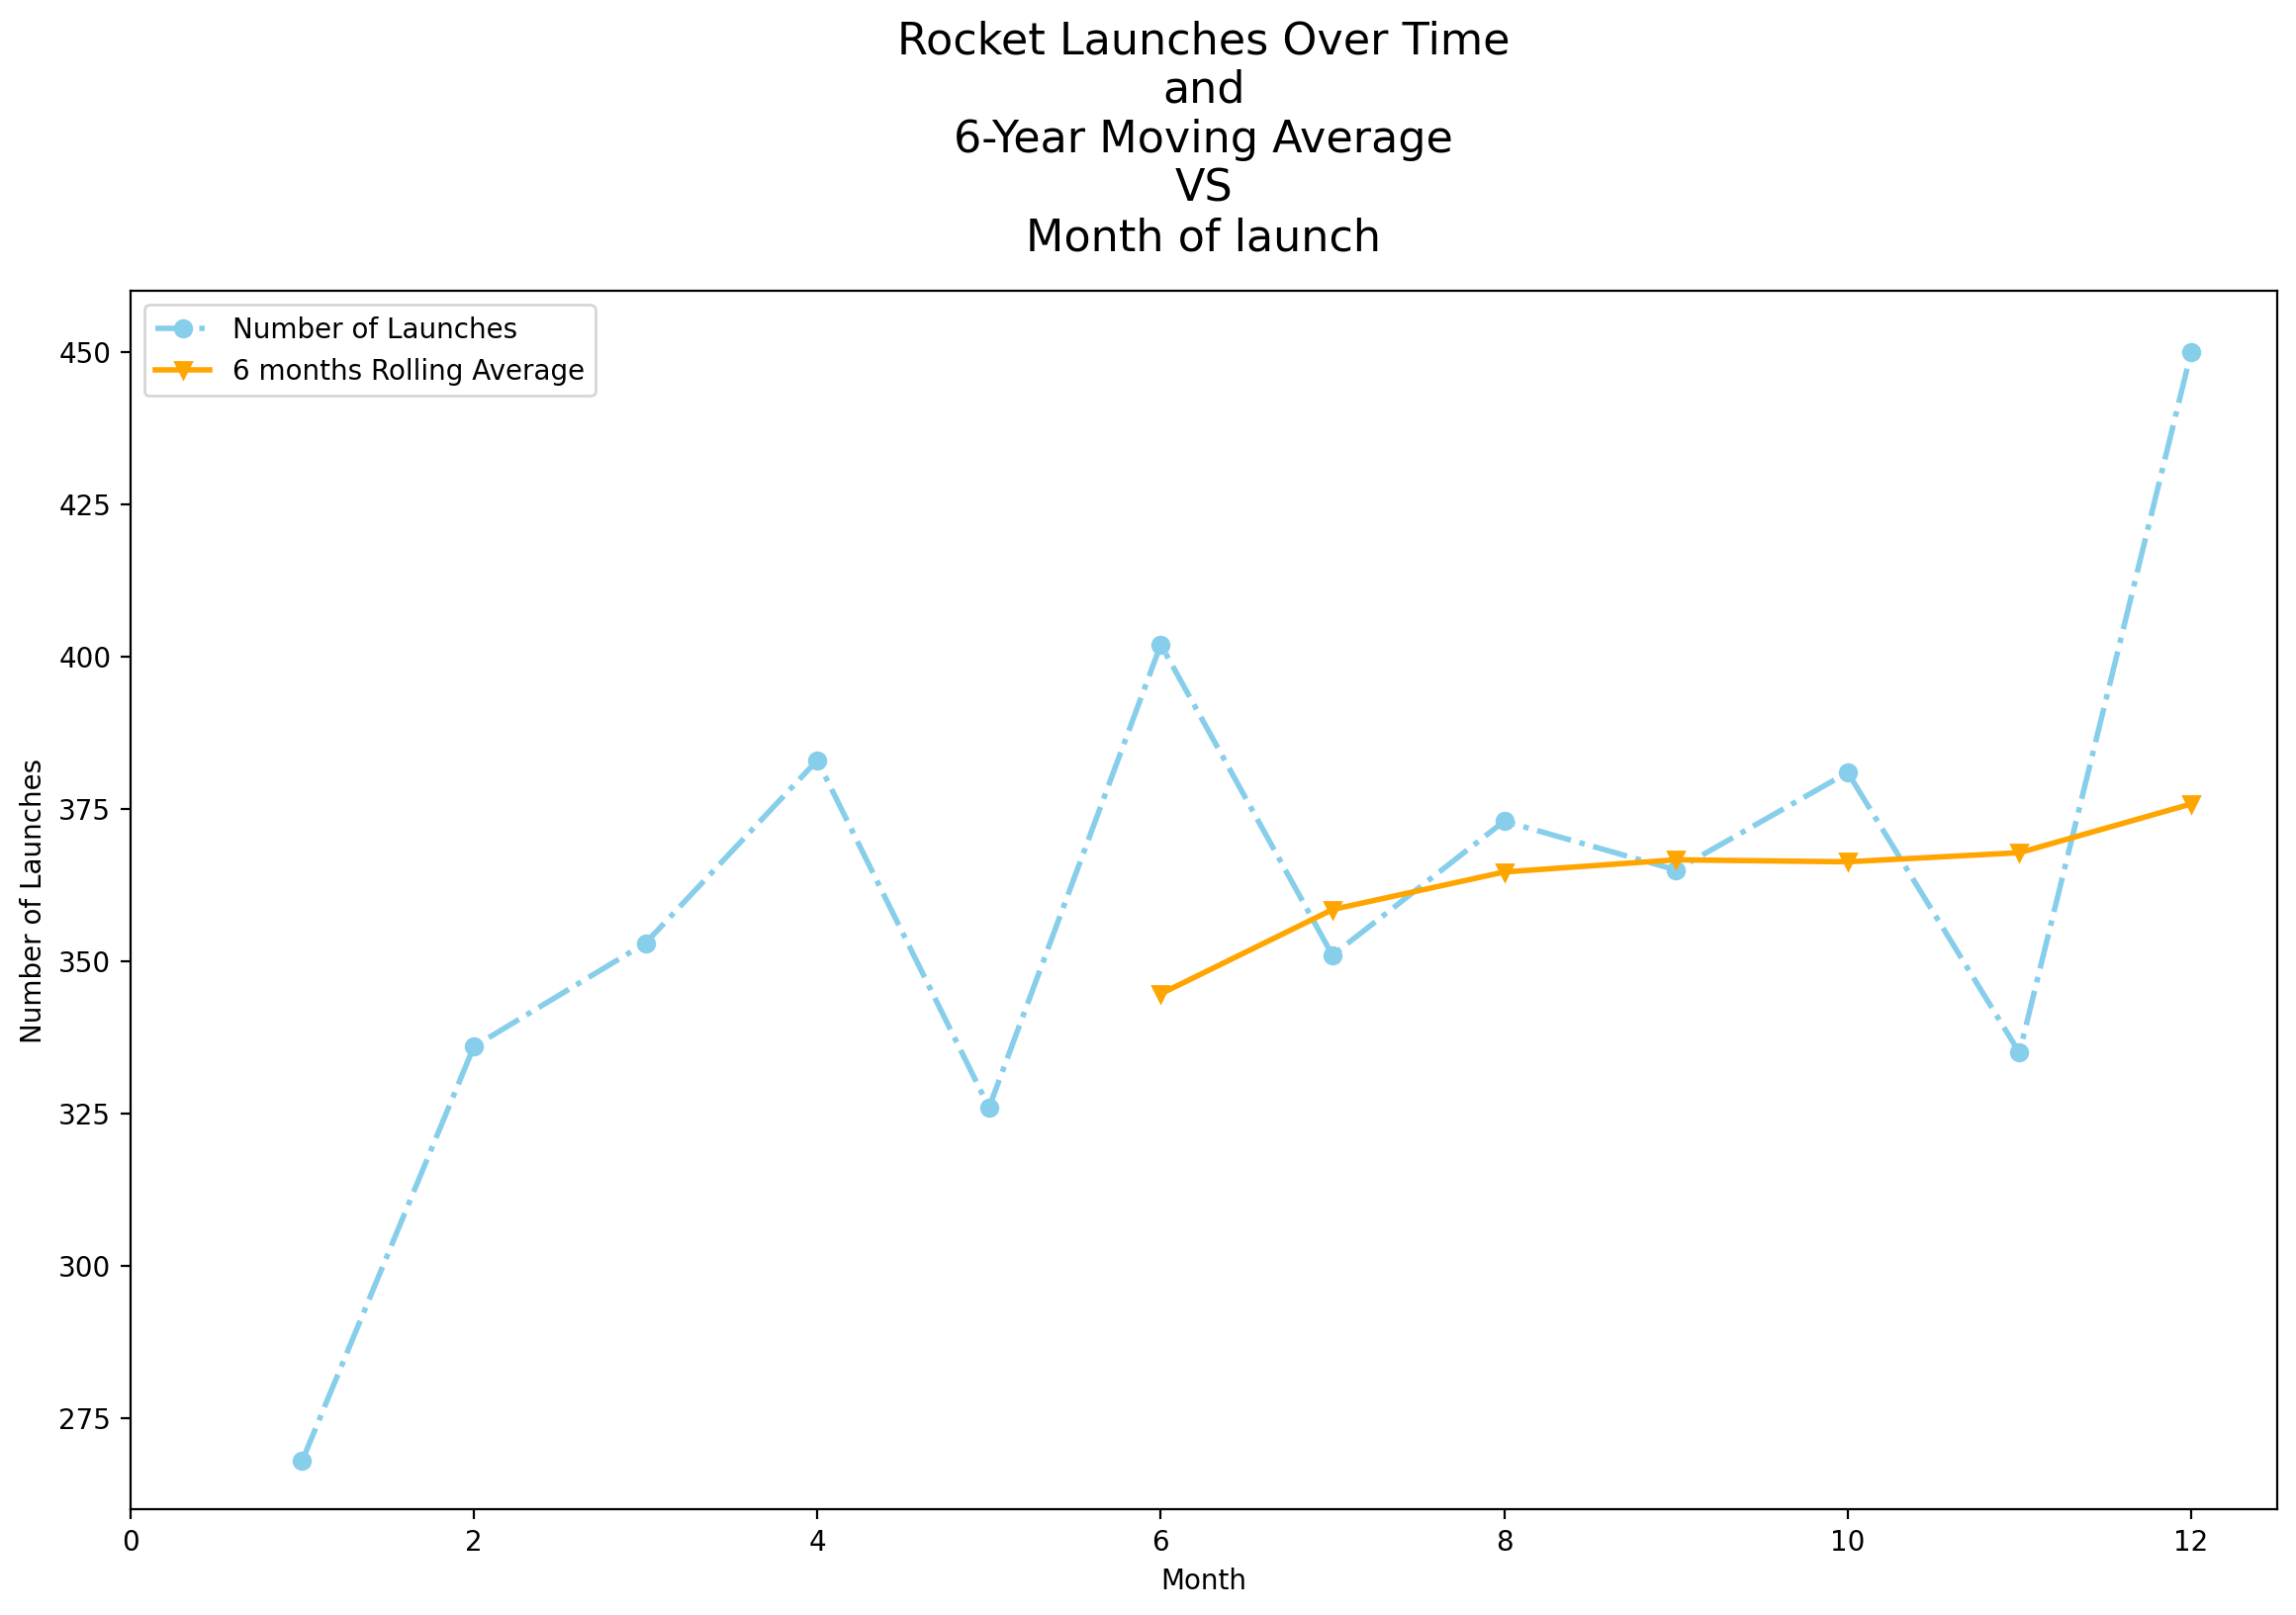

In [ ]:
plt.figure(figsize=(14, 8), dpi = 200)


plt.title(
    'Rocket Launches Over Time\nand\n6-Year Moving Average\nVS\nMonth of launch',
    fontsize=16,
    # fontweight='bold',
    pad=15  # Spacing between title and plot
)


plt.plot(
    launch_by_month_df.Month,
    launch_by_month_df['Launches per month'],
    marker='o',          # Adds scatter dots
    linestyle='-.',       # Connects them with a solid line
    color='skyblue',
    linewidth=2,
    markersize=6,
    label = 'Number of Launches',


)

plt.plot(
    launch_by_month_df.Month,
    launch_by_month_df['Launches per month'].rolling(window = 6).mean(),
    marker='v',          # Adds scatter dots
    linestyle='-',       # Connects them with a solid line
    color='orange',
    linewidth=2,
    markersize=6,
    label = '6 months Rolling Average',


)

plt.xlim((0, 12.5))
plt.xlabel('Month')

plt.ylim((260, 460))
plt.ylabel('Number of Launches')


plt.legend()
plt.show()

In [ ]:
most_popular = launch_by_month_df.idxmax()
least_popular = launch_by_month_df.idxmin()
launch_by_month_df.Month[most_popular]

,Month
11,12
11,12


In [ ]:
launch_by_month_df.Month[least_popular.Month]

np.int32(1)

# How has the Launch Price varied Over Time?

Create a line chart that shows the average price of rocket launches over time.

In [ ]:
monthly_ts_data = clean_df_data.groupby(clean_df_data['Date'].dt.to_period('M'))['Price'].mean().reset_index(name = 'Average Price')


monthly_ts_data= monthly_ts_data[monthly_ts_data['Average Price'] != 0]

print(monthly_ts_data.info())
monthly_ts_data.head()

<class 'pandas.core.frame.DataFrame'>
Index: 388 entries, 77 to 746
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype    
---  ------         --------------  -----    
 0   Date           388 non-null    period[M]
 1   Average Price  388 non-null    float64  
dtypes: float64(1), period[M](1)
memory usage: 9.1 KB
None


/tmp/ipykernel_1166/1941816837.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_ts_data = clean_df_data.groupby(clean_df_data['Date'].dt.to_period('M'))['Price'].mean().reset_index(name = 'Average Price')


,Date,Average Price
77,1964-09,10.54
80,1964-12,12.65
82,1965-02,7.90
85,1965-05,9.03
99,1966-07,5.36


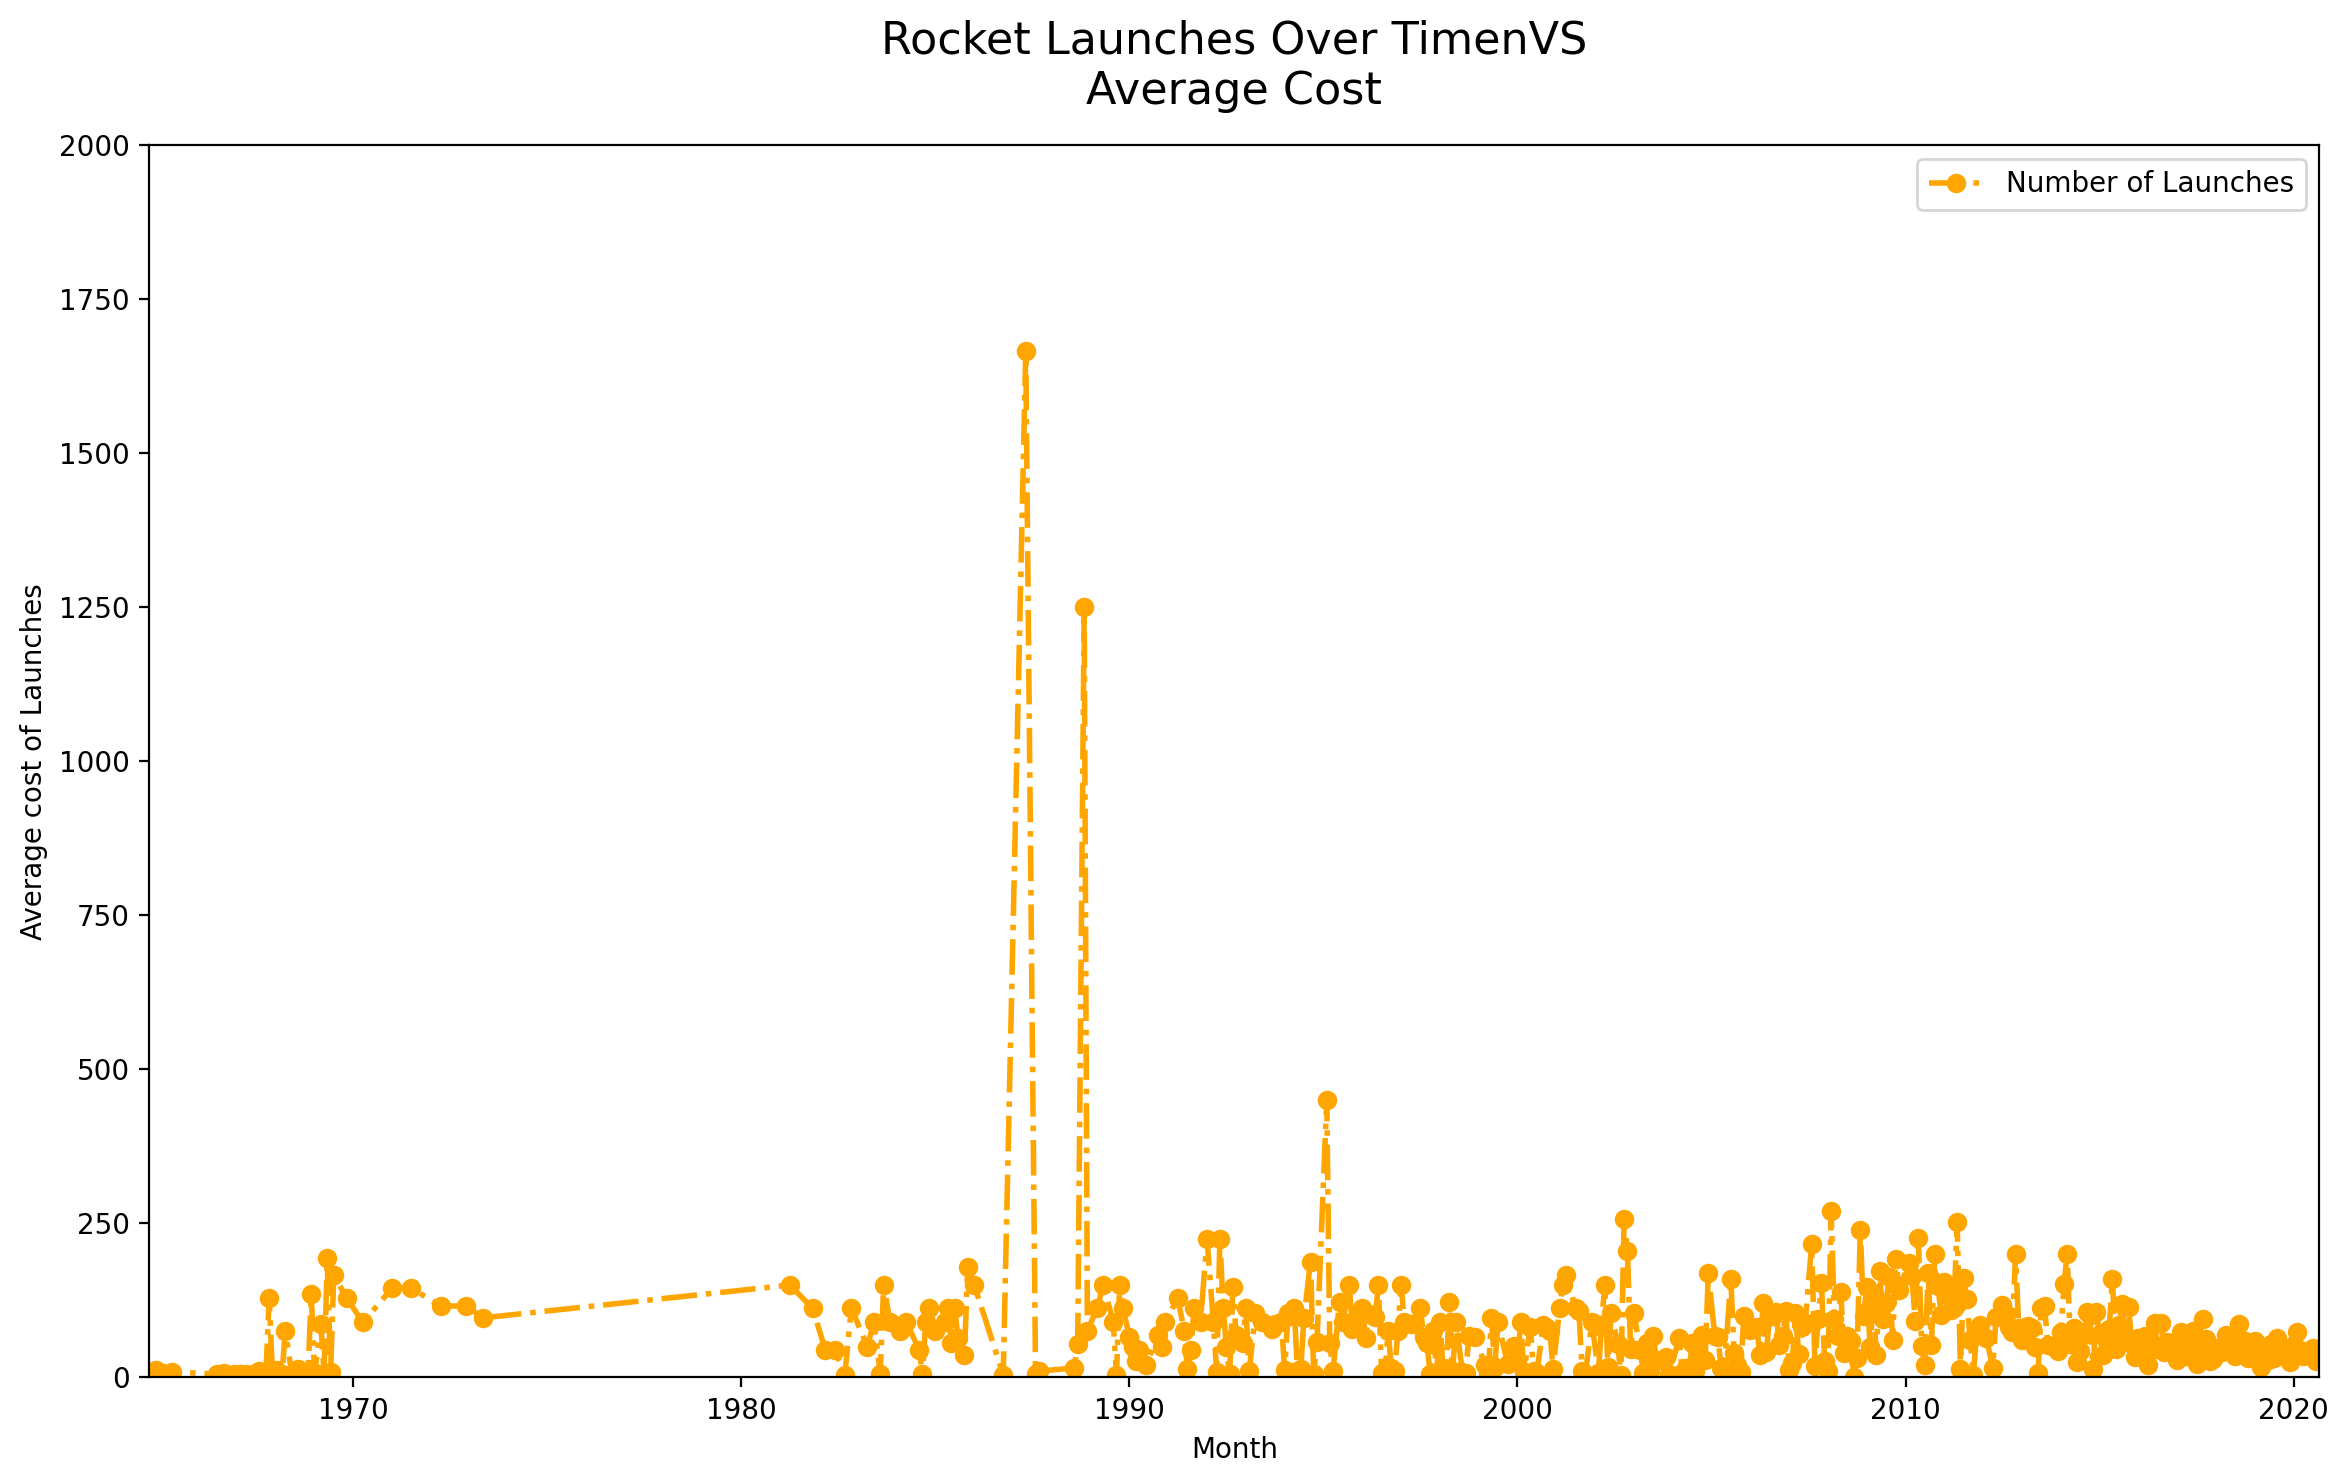

In [ ]:
plt.figure(figsize=(14, 8), dpi = 200)


plt.title(
    'Rocket Launches Over TimenVS\nAverage Cost',
    fontsize=16,
    # fontweight='bold',
    pad=15  # Spacing between title and plot
)


plt.plot(
    monthly_ts_data.Date.dt.to_timestamp(),
    monthly_ts_data['Average Price'],
    marker='o',          # Adds scatter dots
    linestyle='-.',       # Connects them with a solid line
    color='orange',
    linewidth=2,
    markersize=6,
    label = 'Number of Launches',


)

plt.xlim((monthly_ts_data.Date.min(), monthly_ts_data.Date.max()))
plt.xlabel('Month')

plt.ylim((0, 2000))
plt.ylabel('Average cost of Launches')


plt.legend()


plt.show()

# Chart the Number of Launches over Time by the Top 10 Organisations.

How has the dominance of launches changed over time between the different players?

In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4323 non-null   object             
 1   Location        4323 non-null   object             
 2   Date            4323 non-null   datetime64[ns, UTC]
 3   Detail          4323 non-null   object             
 4   Rocket_Status   4323 non-null   object             
 5   Price           4323 non-null   float64            
 6   Mission_Status  4323 non-null   object             
 7   country         4323 non-null   object             
 8   alpha3          4287 non-null   object             
 9   Year            4323 non-null   int32              
 10  Month           4323 non-null   int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(2), object(7)
memory usage: 371.5+ KB


In [ ]:
launch_by_org = clean_df_data.groupby('Organisation').size().reset_index(name = 'Launches').sort_values(ascending=False, by='Launches')
launch_by_org = launch_by_org[:15]
launch_by_org

,Organisation,Launches
40,RVSN USSR,1777
3,Arianespace,279
17,General Dynamics,251
7,CASC,250
35,NASA,203
52,VKS RF,201
49,US Air Force,161
48,ULA,140
6,Boeing,136
34,Martin Marietta,114


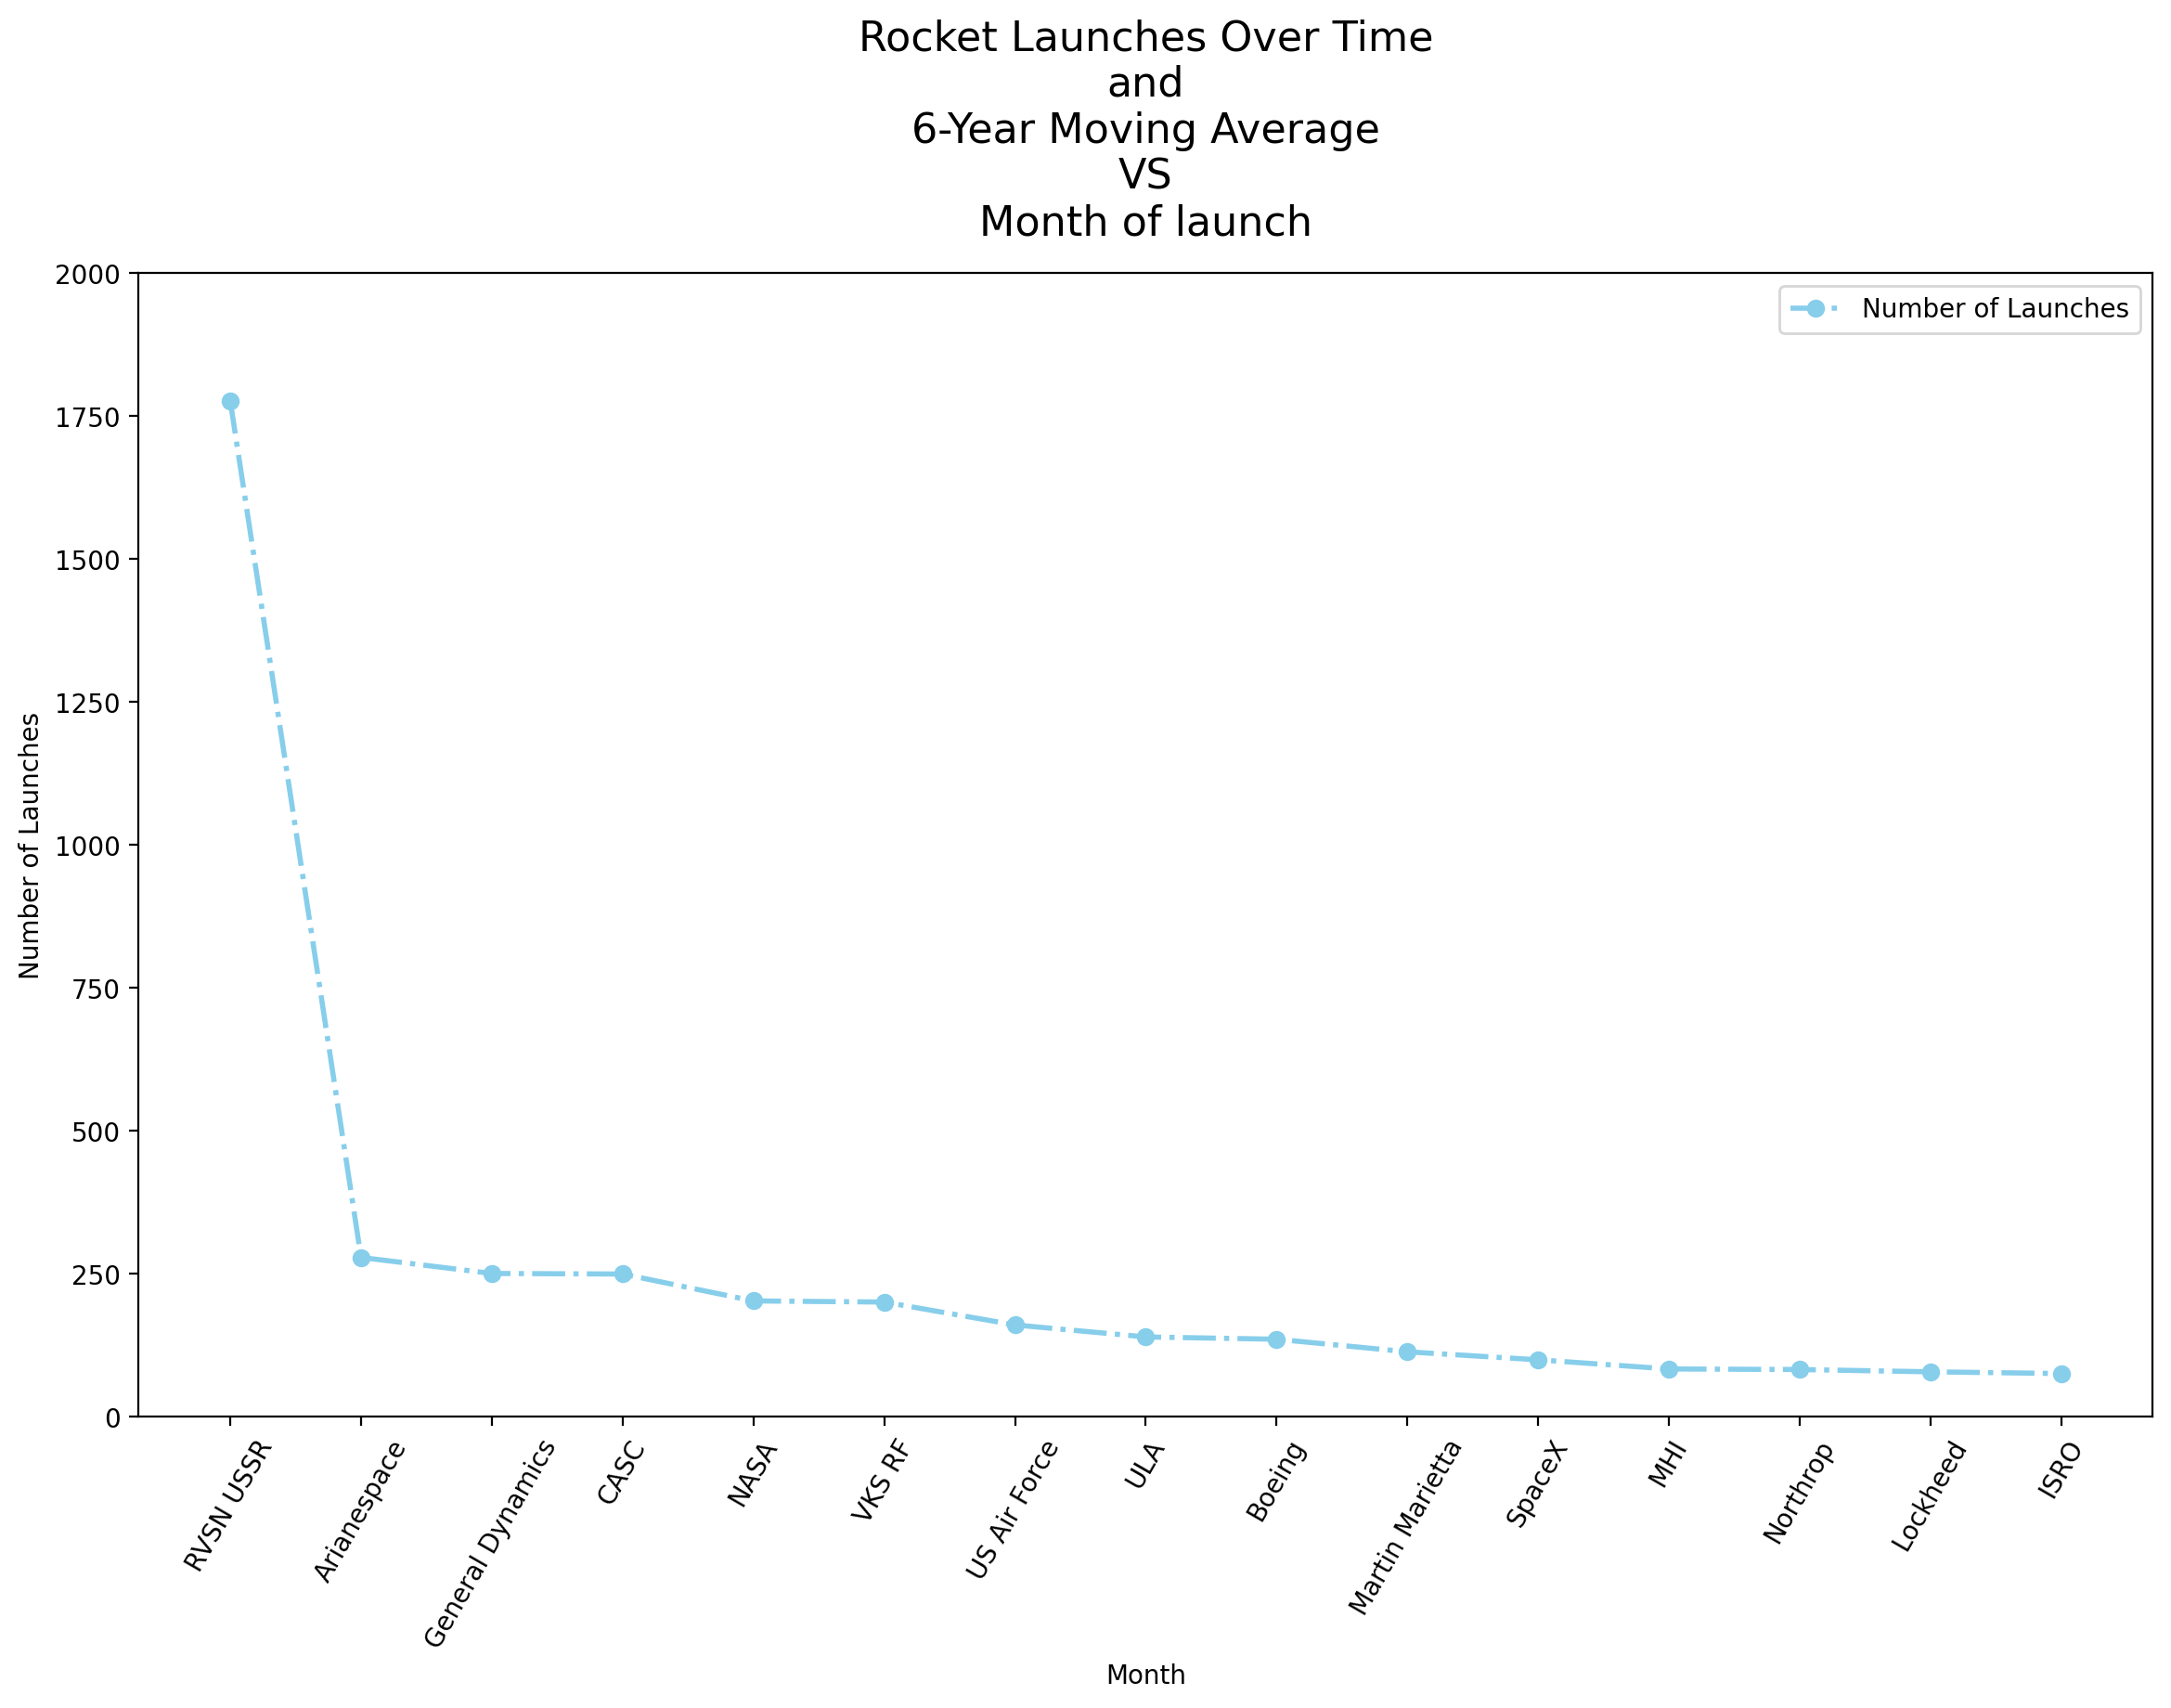

In [ ]:
plt.figure(figsize=(14, 8), dpi = 200)


plt.title(
    'Rocket Launches Over Time\nand\n6-Year Moving Average\nVS\nMonth of launch',
    fontsize=16,
    # fontweight='bold',
    pad=15  # Spacing between title and plot
)


plt.plot(
    launch_by_org.Organisation,
    launch_by_org.Launches,
    marker='o',          # Adds scatter dots
    linestyle='-.',       # Connects them with a solid line
    color='skyblue',
    linewidth=2,
    markersize=6,
    label = 'Number of Launches',


)

# plt.xlim((0, 12.5))
plt.xticks( launch_by_org.Organisation, rotation= 60)
plt.xlabel('Month')

plt.ylim((0, 2000))
plt.ylabel('Number of Launches')


plt.legend()
plt.show()

# Cold War Space Race: USA vs USSR

The cold war lasted from the start of the dataset up until 1991.

In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4323 non-null   object             
 1   Location        4323 non-null   object             
 2   Date            4323 non-null   datetime64[ns, UTC]
 3   Detail          4323 non-null   object             
 4   Rocket_Status   4323 non-null   object             
 5   Price           4323 non-null   float64            
 6   Mission_Status  4323 non-null   object             
 7   country         4323 non-null   object             
 8   alpha3          4287 non-null   object             
 9   Year            4323 non-null   int32              
 10  Month           4323 non-null   int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(2), object(7)
memory usage: 371.5+ KB


In [ ]:
coldwar_data = clean_df_data[((clean_df_data.country == 'USA') | (clean_df_data.country == 'Russian Fedaration')) &  (clean_df_data.Year <= 1991 )]
coldwar_data

,Organisation,Location,Date,Detail,Rocket_Status,Price,Mission_Status,country,alpha3,Year,Month
1719,Yuzhmash,"Site 32/2, Plesetsk Cosmodrome, Russia",1991-12-18 03:54:00+00:00,Tsyklon-3 | Intercosmos 25 & Magion 3,StatusRetired,0.00,Success,Russian Fedaration,RUS,1991,12
1721,General Dynamics,"SLC-36B, Cape Canaveral AFS, Florida, USA",1991-12-07 22:47:00+00:00,Atlas II | Eutelsat 2F3,StatusRetired,0.00,Success,USA,USA,1991,12
1722,General Dynamics,"SLC-3W, Vandenberg AFB, California, USA",1991-11-28 13:23:00+00:00,Atlas-E/F Star-37S-ISS | DMSP F-11,StatusRetired,0.00,Success,USA,USA,1991,11
1723,RVSN USSR,"Site 133/3, Plesetsk Cosmodrome, Russia",1991-11-27 03:30:00+00:00,Cosmos-3M (11K65M) | Cosmos 2173,StatusRetired,0.00,Success,Russian Fedaration,RUS,1991,11
1724,NASA,"LC-39A, Kennedy Space Center, Florida, USA",1991-11-24 23:44:00+00:00,Space Shuttle Atlantis | STS-44,StatusRetired,450.00,Success,USA,USA,1991,11
...,...,...,...,...,...,...,...,...,...,...,...
4317,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-03-17 12:15:00+00:00,Vanguard | Vanguard 1,StatusRetired,0.00,Success,USA,USA,1958,3
4318,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-03-05 18:27:00+00:00,Juno I | Explorer 2,StatusRetired,0.00,Failure,USA,USA,1958,3
4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA",1958-02-05 07:33:00+00:00,Vanguard | Vanguard TV3BU,StatusRetired,0.00,Failure,USA,USA,1958,2
4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA",1958-02-01 03:48:00+00:00,Juno I | Explorer 1,StatusRetired,0.00,Success,USA,USA,1958,2


## Create a Plotly Pie Chart comparing the total number of launches of the USSR and the USA

Hint: Remember to include former Soviet Republics like Kazakhstan when analysing the total number of launches.

In [ ]:
coldwar_sunborst = px.sunburst(
    coldwar_data,
    path= ['country', 'Organisation', 'Mission_Status']
)

coldwar_bar = px.bar(
    coldwar_data.groupby(['country', 'Mission_Status']).size().reset_index(name = 'No_of_launches'),
    x = 'country',
    y = 'No_of_launches',
    color = 'Mission_Status',

)




coldwar_sunborst.show()
coldwar_bar.show()

<!doctype html>

<!doctype html>

## Create a Chart that Shows the Total Number of Launches Year-On-Year by the Two Superpowers

In [ ]:
coldwar_bar = px.histogram(
    coldwar_data.groupby(['country', 'Year']).size().reset_index(name = 'No_of_launches'),
    x="Year",
    y='No_of_launches',
    color='country',
    barmode='group',
    # height=400
    # width= 10

  )

coldwar_bar.update_traces(xbins=dict(
    # start=0,  # Where bins start
    # end=60,  # Where bins end
    size=1  # Width of each bin
))

coldwar_bar.show()

<!doctype html>

## Chart the Total Number of Mission Failures Year on Year.

In [ ]:
coldwar_bar_failure = px.histogram(
    # dataset
    coldwar_data[(coldwar_data['Mission_Status']=='Failure') | (coldwar_data['Mission_Status']=='Partial Failure')].groupby(['country', 'Year']).size().reset_index(name = 'No_of_launches'),

    # specification
    x="Year",
    y='No_of_launches',
    color='country',
    barmode='group',
    # height=400,
    # width= 10,
    title= "FAILURE VS COUNTRY"

  )

coldwar_bar.update_traces(xbins=dict(
    # start=0,  # Where bins start
    # end=60,  # Where bins end
    size=1  # Width of each bin
))

coldwar_bar.show()

<!doctype html>

## Chart the Percentage of Failures over Time

Did failures go up or down over time? Did the countries get better at minimising risk and improving their chances of success over time?

In [ ]:
failure_part = coldwar_data[(coldwar_data['Mission_Status']=='Failure') | (coldwar_data['Mission_Status']=='Partial Failure')].groupby(['country' ,'Year']).size().reset_index(name = 'Failure Count')

success_part = coldwar_data[coldwar_data['Mission_Status']=='Success'].groupby(['country' ,'Year']).size().reset_index(name = 'Success Count')
fail_success_dataset  = pd.merge( success_part, failure_part, how='left').replace(np.nan, 0)

fail_success_dataset['Percentage Failure'] = fail_success_dataset['Failure Count']*100 / (fail_success_dataset['Success Count'] + fail_success_dataset['Failure Count'])

fail_success_dataset

,country,Year,Success Count,Failure Count,Percentage Failure
0,Russian Fedaration,1962,7,1.00,12.50
1,Russian Fedaration,1963,4,4.00,50.00
2,Russian Fedaration,1964,7,1.00,12.50
3,Russian Fedaration,1965,7,3.00,30.00
4,Russian Fedaration,1966,13,2.00,13.33
...,...,...,...,...,...
59,USA,1987,5,1.00,16.67
60,USA,1988,6,1.00,14.29
61,USA,1989,16,0.00,0.00
62,USA,1990,25,1.00,3.85


In [ ]:
coldwar_bar = px.histogram(
    fail_success_dataset,
    x="Year",
    y='Percentage Failure',
    color='country',
    barmode='group',
    # height=400
    # width= 10

  )

coldwar_bar.update_traces(
    xbins=dict(
    # start=0,  # Where bins start
    # end=60,  # Where bins end
    size=1  # Width of each bin
    )
)

coldwar_bar.show()

<!doctype html>

# For Every Year Show which Country was in the Lead in terms of Total Number of Launches up to and including including 2020)

Do the results change if we only look at the number of successful launches?

In [ ]:
max_launch_by_country = clean_df_data.groupby('Year' )['country'].max()
max_launch_by_country

,country
Year,
1957,USA
1958,USA
1959,USA
1960,USA
1961,USA
...,...
2016,USA
2017,USA
2018,USA


# Create a Year-on-Year Chart Showing the Organisation Doing the Most Number of Launches

Which organisation was dominant in the 1970s and 1980s? Which organisation was dominant in 2018, 2019 and 2020?

In [ ]:
clean_df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4323 entries, 0 to 4323
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Organisation    4323 non-null   object             
 1   Location        4323 non-null   object             
 2   Date            4323 non-null   datetime64[ns, UTC]
 3   Detail          4323 non-null   object             
 4   Rocket_Status   4323 non-null   object             
 5   Price           4323 non-null   float64            
 6   Mission_Status  4323 non-null   object             
 7   country         4323 non-null   object             
 8   alpha3          4287 non-null   object             
 9   Year            4323 non-null   int32              
 10  Month           4323 non-null   int32              
dtypes: datetime64[ns, UTC](1), float64(1), int32(2), object(7)
memory usage: 371.5+ KB


In [ ]:
max_launch_by_org = clean_df_data.groupby('Year' )['Organisation'].max()
max_launch_by_org

,Organisation
Year,
1957,US Navy
1958,US Navy
1959,US Navy
1960,US Air Force
1961,US Air Force
...,...
2016,VKS RF
2017,VKS RF
2018,VKS RF


In [ ]:
max_launch_by_org[(max_launch_by_org.index <= 1979) & (max_launch_by_org.index >= 1970)]

,Organisation
Year,
1970,UT
1971,US Air Force
1972,US Air Force
1973,US Air Force
1974,US Air Force
1975,US Air Force
1976,US Air Force
1977,US Air Force
1978,RVSN USSR


In [ ]:
max_launch_by_org[(max_launch_by_org.index <= 1989) & (max_launch_by_org.index >= 1980)]

,Organisation
Year,
1980,RVSN USSR
1981,US Air Force
1982,US Air Force
1983,US Air Force
1984,US Air Force
1985,RVSN USSR
1986,RVSN USSR
1987,RVSN USSR
1988,RVSN USSR


In [ ]:
max_launch_by_org[max_launch_by_org.index >= 2018]

,Organisation
Year,
2018,VKS RF
2019,i-Space
2020,Virgin Orbit
